# Slippage Feature EDA — Route Decay Analysis

Analysis of route decay across 9 DEX protocols on Ethereum mainnet.
This notebook studies how quoted swap outputs degrade over time, what
drives that degradation, and which features can predict high-risk
routes — with the goal of reducing transaction revert rates.

## Methodology

### What we measure

When Fynd receives a swap request, it finds the optimal route across
9 DEX protocols and returns a quoted output amount. Between the quote
and on-chain execution (1-10 Ethereum blocks, ~12-120 seconds), pool
states change and the actual output may differ from the quote. We call
this difference **route decay**.

If decay exceeds the user's slippage tolerance, the transaction
**reverts** — the user pays gas but receives nothing. Understanding
what drives decay is the first step toward predicting and preventing
reverts.

### Data collection

We run a **prospective collection** system: a quote driver replays a
sample of 1,000 real aggregator trades every 5 minutes through a live
Fynd instance. For each quote, the system resimulates the route at
blocks +1 through +10 using Tycho's pool simulation engine, measuring
both the total route output and per-hop amounts at each offset.

A separate Fynd instance handles **re-quote decomposition**: at each
offset, we also request a fresh quote for the same trade. This lets
us decompose total decay into:
- **Market movement**: how much the optimal output changed (unavoidable)
- **Execution slippage**: additional loss from the original route
  becoming suboptimal (potentially reducible)

### Data schema

The analysis uses three datasets joined into a unified view:

| Source | Grain | Key columns |
|--------|-------|-------------|
| **Quote log** | 1 row per quote | token_in/out, amount_in/out, gas_estimate, route_json |
| **Tycho route decay** | 1 row per quote × offset | route_decay_bps, market_movement_bps, execution_slippage_bps |
| **Hop decay** | 1 row per hop × offset | hop_decay_bps, protocol, fee_tier, depth_at_1pct |

Computed features include hop_count, split_count, pair_bucket
(token pair classification by market cap), and temporal features
(hour_of_day, day_of_week estimated from block number).

### Protocols covered

uniswap_v2, uniswap_v3, uniswap_v4, sushiswap_v2, pancakeswap_v2,
pancakeswap_v3, ekubo_v2, ekubo_v3, fluid_v1.

### Decomposition limitations

The market movement / execution slippage decomposition is measured by
re-quoting the same trade through a separate Fynd instance at each
block offset. This has limitations:

- **Re-quote variability**: BellmanFord's SPFA is order-dependent, so
  two quotes for the same trade at the same block can return different
  routes. Some measured "market movement" may reflect solver
  non-determinism rather than true price changes.
- **Solver improvement conflation**: If a better pool becomes available,
  the re-quote captures it as "market movement" even though it
  represents a solver improvement opportunity, not an unavoidable
  market force.
- **State synchronization**: The re-quote instance may have slightly
  different Tycho state than the primary, introducing measurement noise.

These factors mean the 65/35 market-movement/execution-slippage split
should be treated as directionally informative, not precise.

### Statistical notes

- All means are **winsorized** at P1-P99 unless stated otherwise,
  to prevent extreme outliers from distorting averages.
- Statistical tests use non-parametric methods (Kruskal-Wallis,
  Spearman correlation) since decay distributions are heavy-tailed
  and non-normal.
- Sample sizes are shown on all figures. Results from groups with
  fewer than 100 observations should be interpreted with caution.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib
try:
    get_ipython()
    matplotlib.use("module://matplotlib_inline.backend_inline")
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
FIGSIZE = (12, 6)
COLORS = sns.color_palette("deep", 10)

def find_workspace_root() -> Path:
    p = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
    while p != p.parent:
        cargo = p / "Cargo.toml"
        if cargo.exists() and "[workspace]" in cargo.read_text():
            return p
        p = p.parent
    raise FileNotFoundError("workspace root not found")

PROJECT_ROOT = find_workspace_root()
DATA_DIR = PROJECT_ROOT / "slippage-data"
UNIFIED_PATH = DATA_DIR / "unified" / "chain_id=1" / "unified.parquet"
HOP_DECAY_DIR = DATA_DIR / "hop_decay_eda" if (DATA_DIR / "hop_decay_eda").exists() else DATA_DIR / "hop_decay"
HOP_STATIC_DIR = DATA_DIR / "hop_static_eda" if (DATA_DIR / "hop_static_eda").exists() else DATA_DIR / "hop_static"
FIG_DIR = PROJECT_ROOT / "tools" / "slippage-features" / "notebooks" / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

P1_CAP = None
P99_CAP = None

## Glossary

- **bps** (basis points): 1 bps = 0.01%. A swap quoted at 1000 USDC
  with 5 bps decay delivers 999.50 USDC.
- **decay**: (amount_at_quote_block - amount_at_later_block) /
  amount_at_quote_block, in bps. Positive = user receives less than quoted.
- **block offset**: number of Ethereum blocks (~12 seconds each) between
  when a quote was given and when execution is simulated.
- **hop**: a single pool swap within a multi-pool route.
  ETH->USDC->DAI = 2 hops.
- **winsorized mean**: values capped at P1 and P99 percentiles to prevent
  extreme outliers from distorting averages.
- **pair_bucket**: token pair classification by market cap (stable,
  blue_chip >$10B, mid_cap >$100M, long_tail >$1M, meme <$1M).
- **market movement**: decay from price changes in the wider market
  (unavoidable).
- **execution slippage**: additional decay from the original route
  becoming suboptimal (potentially reducible by Fynd).

## Executive Summary

- **Dataset**: 297,712 quotes across 9 DEX protocols over 44.5 hours
- **Revert risk**: ~1.1% of routes decay by >20 bps within 2 minutes of quoting
- **Root cause split**: 65% of decay is market movement (not controllable);
  35% is execution slippage (within Fynd's control to improve)
- **Strongest predictors**: Fee tier, protocol type, pair type, and hop count
  predict which routes will decay most
- **Pair types** (CoinGecko-enriched, 13 categories): `longtail-meme` has the
  highest raw mean decay (3.76 bps); `stable-meme` and `mid-mid` show negative
  mean decay (routes improve); `stable-large` (1.36 bps) is the highest-volume
  high-decay category
- **Highest-risk routes**: ekubo_v3 (4.1 bps mean decay), pancakeswap_v3
  (2.8 bps), multi-hop routes through low-fee volatile pools
- **Next step**: Build a prediction model to flag high-risk routes at quote
  time and apply per-route slippage tolerances

## 1. Load Data

In [2]:
df = pl.read_parquet(UNIFIED_PATH)
print(f"Unified: {df.shape[0]:,} rows, {df['quote_id'].n_unique():,} quotes, {df.shape[1]} columns")

blocks = df["block_number"]
span_blocks = blocks.max() - blocks.min()
span_hours = span_blocks * 12 / 3600
print(f"Block range: {blocks.min():,} → {blocks.max():,} ({span_blocks:,} blocks, ~{span_hours:.1f}h)")
print(f"Offsets: {sorted(df['block_offset'].unique().to_list())}")

Unified: 2,863,603 rows, 297,712 quotes, 30 columns
Block range: 25,203,070 → 25,216,410 (13,340 blocks, ~44.5h)
Offsets: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [3]:
# Load hop-level data in batches for memory efficiency
import time

def load_batched(directory, label, batch_size=5000):
    files = sorted(directory.glob("*.parquet"))
    if not files:
        return pl.DataFrame()
    frames = []
    t0 = time.time()
    for i in range(0, len(files), batch_size):
        batch = files[i:i+batch_size]
        frames.append(pl.concat([pl.read_parquet(f) for f in batch]))
        done = min(i + batch_size, len(files))
        if done % 50000 == 0 or done == len(files):
            print(f"  {label}: {done:,}/{len(files):,} files ({time.time()-t0:.0f}s)")
    return pl.concat(frames)

print("Loading hop-level data...")
hd = load_batched(HOP_DECAY_DIR, "hop_decay")
hs = load_batched(HOP_STATIC_DIR, "hop_static")
hd_full = hd.join(hs, on=["quote_id", "solver_id", "hop_index"], how="left")
print(f"Hop decay: {hd.shape[0]:,} rows | Hop static: {hs.shape[0]:,} rows")

Loading hop-level data...


  hop_decay: 50,000/297,712 files (86s)


  hop_decay: 100,000/297,712 files (169s)


  hop_decay: 150,000/297,712 files (237s)


  hop_decay: 200,000/297,712 files (293s)


...

  hop_static: 150,000/297,712 files (168s)


  hop_static: 200,000/297,712 files (223s)


  hop_static: 250,000/297,712 files (284s)


  hop_static: 297,712/297,712 files (343s)


Hop decay: 4,547,135 rows | Hop static: 472,751 rows


## 2. Data Quality Assessment

In [4]:
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

print(f"\n--- Collection Overview ---")
print(f"Observation period: ~{span_hours:.1f} hours ({span_blocks:,} blocks)")
print(f"Total quotes: {df['quote_id'].n_unique():,}")
print(f"Total rows (quote × offset): {df.shape[0]:,}")
print(f"Expected rows (quotes × 10 offsets): {df['quote_id'].n_unique() * 10:,}")
completeness = 100 * df.shape[0] / (df['quote_id'].n_unique() * 10)
print(f"Completeness: {completeness:.1f}%")

print(f"\n--- Null Rates ---")
print(f"{'column':>35} {'nulls':>10} {'total':>10} {'pct':>7}")
for col in df.columns:
    nulls = df[col].null_count()
    pct = 100 * nulls / df.shape[0]
    flag = " ⚠" if pct > 50 else ""
    if nulls > 0:
        print(f"{col:>35} {nulls:10,} {df.shape[0]:10,} {pct:6.1f}%{flag}")

mm_fill = df.filter(pl.col("market_movement_bps").is_not_null()).shape[0]
print(f"\n--- Decomposition Fill Rate ---")
print(f"market_movement_bps filled: {mm_fill:,}/{df.shape[0]:,} ({100*mm_fill/df.shape[0]:.1f}%)")

print(f"\n--- Pair Classification Coverage ---")
pair_counts = df.group_by("pair_bucket").agg(pl.len().alias("n")).sort("n", descending=True)
print(f"{'pair_bucket':>25} {'count':>10} {'pct':>7}")
for row in pair_counts.iter_rows(named=True):
    print(f"{row['pair_bucket']:>25} {row['n']:10,} {100*row['n']/df.shape[0]:6.1f}%")

mcap_null = df["log_mcap_ratio"].null_count()
print(f"\nlog_mcap_ratio null: {mcap_null:,}/{df.shape[0]:,} ({100*mcap_null/df.shape[0]:.1f}%)")
print(f"NOTE: Remaining mcap nulls are tokens not found on CoinGecko (delisted,")
print(f"wrapped, or non-standard). These default to 'long_tail' classification.")

print(f"\n--- Protocol Coverage (hop level) ---")
proto_counts = hd_full.group_by("protocol").agg(pl.len().alias("n")).sort("n", descending=True)
print(f"{'protocol':>20} {'hops':>10}")
for row in proto_counts.iter_rows(named=True):
    print(f"{row['protocol']:>20} {row['n']:10,}")

DATA QUALITY REPORT

--- Collection Overview ---
Observation period: ~44.5 hours (13,340 blocks)
Total quotes: 297,712
Total rows (quote × offset): 2,863,603
Expected rows (quotes × 10 offsets): 2,977,120


Completeness: 96.2%

--- Null Rates ---
                             column      nulls      total     pct
             gap_to_second_best_bps  2,863,603  2,863,603  100.0% ⚠
                     log_mcap_ratio     88,825  2,863,603    3.1%
                           min_mcap     64,502  2,863,603    2.3%
                           max_mcap     64,502  2,863,603    2.3%
                market_movement_bps      1,387  2,863,603    0.0%
             execution_slippage_bps      1,387  2,863,603    0.0%

--- Decomposition Fill Rate ---
market_movement_bps filled: 2,862,216/2,863,603 (100.0%)

--- Pair Classification Coverage ---
              pair_bucket      count     pct
             stable-large  1,040,600   36.3%
               stable-mid    520,209   18.2%
                large-mid    307,652   10.7%
          stable-longtail    246,907    8.6%
           large-longtail    243,922    8.5%
            stable-stable    205,981    7.2%
                  mid-mid    158,983    5.6%
        

In [5]:
# Temporal coverage: check for gaps
blocks_at_5 = df.filter(pl.col("block_offset") == 5)["block_number"].sort()
block_list = blocks_at_5.unique().sort().to_numpy()
if len(block_list) > 1:
    gaps = np.diff(block_list)
    big_gaps = gaps[gaps > 100]
    print(f"\n--- Temporal Gaps (>100 blocks = ~20 min) ---")
    print(f"Unique blocks observed: {len(block_list):,}")
    if len(big_gaps) > 0:
        print(f"Gaps > 100 blocks: {len(big_gaps)}")
        for g in sorted(big_gaps, reverse=True)[:10]:
            print(f"  {g} blocks (~{g*12/60:.0f} min)")
    else:
        print("No significant temporal gaps detected.")


--- Temporal Gaps (>100 blocks = ~20 min) ---
Unique blocks observed: 3,812
No significant temporal gaps detected.


## 3. Decay Distribution & Outlier Analysis

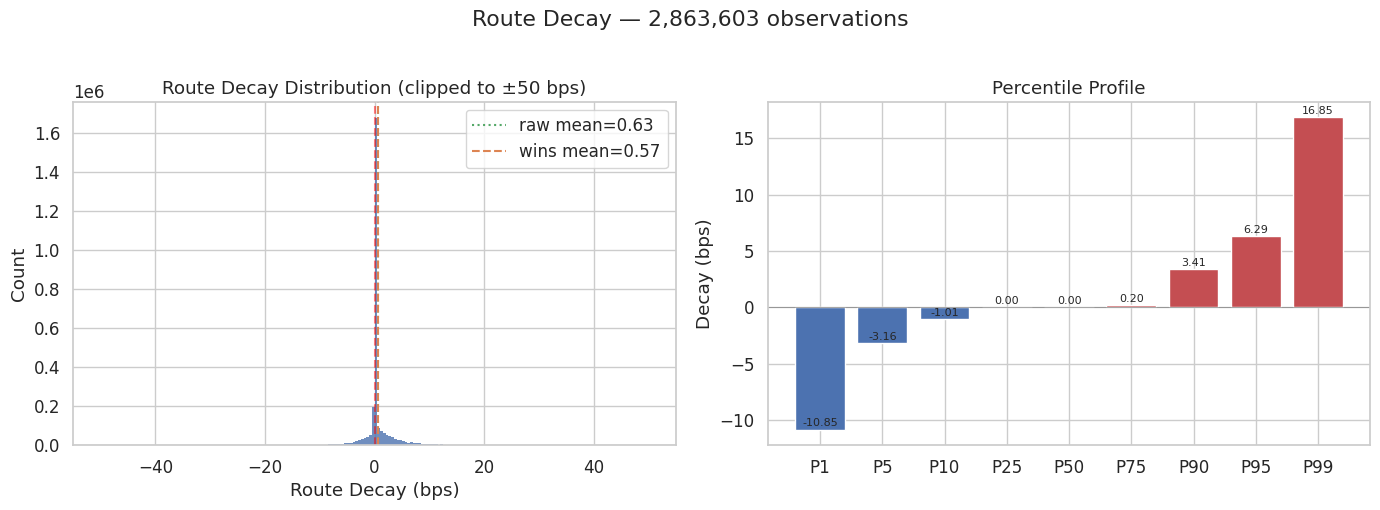

In [6]:
decay = df["route_decay_bps"].to_numpy()
decay_clean = decay[np.isfinite(decay)]
P1_CAP = np.percentile(decay_clean, 1)
P99_CAP = np.percentile(decay_clean, 99)
capped = np.clip(decay_clean, P1_CAP, P99_CAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(decay_clean, bins=200, range=(-50, 50), color=COLORS[0], alpha=0.8, edgecolor="none")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Route Decay (bps)")
axes[0].set_ylabel("Count")
axes[0].set_title("Route Decay Distribution (clipped to ±50 bps)")
raw_mean = np.mean(decay_clean)
wins_mean = np.mean(capped)
axes[0].axvline(raw_mean, color=COLORS[2], linestyle=":", label=f"raw mean={raw_mean:.2f}")
axes[0].axvline(wins_mean, color=COLORS[1], linestyle="--", label=f"wins mean={wins_mean:.2f}")
axes[0].legend()

pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
vals = [np.percentile(decay_clean, p) for p in pcts]
axes[1].bar([f"P{p}" for p in pcts], vals, color=[COLORS[3] if v >= 0 else COLORS[0] for v in vals])
axes[1].set_ylabel("Decay (bps)")
axes[1].set_title("Percentile Profile")
axes[1].axhline(0, color="grey", linewidth=0.5)
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.3, f"{v:.2f}", ha="center", fontsize=8)

fig.suptitle(f"Route Decay — {len(decay_clean):,} observations", y=1.02)
fig.tight_layout()
save(fig, "01_decay_distribution")

In [7]:
neg = (decay_clean < 0).sum()
zero = (decay_clean == 0).sum()
pos = (decay_clean > 0).sum()
n = len(decay_clean)
print(f"Improved (decay < 0): {neg:,} ({100*neg/n:.1f}%)")
print(f"Unchanged (decay = 0): {zero:,} ({100*zero/n:.1f}%)")
print(f"Degraded (decay > 0): {pos:,} ({100*pos/n:.1f}%)")
print(f"\nRaw:       mean={np.mean(decay_clean):.3f} bps, std={np.std(decay_clean):.2f}")
print(f"Winsorized (P1-P99): mean={np.mean(capped):.3f} bps, std={np.std(capped):.2f}")
print(f"\nP1={P1_CAP:.2f}, P99={P99_CAP:.2f}, Max={np.max(decay_clean):.1f}")

Improved (decay < 0): 540,668 (18.9%)
Unchanged (decay = 0): 1,330,310 (46.5%)
Degraded (decay > 0): 992,625 (34.7%)

Raw:       mean=0.626 bps, std=20.02
Winsorized (P1-P99): mean=0.566 bps, std=3.29

P1=-10.85, P99=16.85, Max=3797.8


In [8]:
print("\n=== Outlier characterization ===")
for threshold in [20, 50, 100, 500, 1000]:
    above = (decay_clean > threshold).sum()
    below = (decay_clean < -threshold).sum()
    if above > 0 or below > 0:
        print(f"  |decay| > {threshold} bps: {above} above, {below} below ({100*(above+below)/n:.3f}%)")

extreme = df.filter(pl.col("route_decay_bps") > 500)
if extreme.height > 0:
    print(f"\nRoutes with >500 bps decay:")
    by_bucket = extreme["pair_bucket"].value_counts().sort("count", descending=True)
    for row in by_bucket.head(5).iter_rows(named=True):
        print(f"  {row['pair_bucket']}: {row['count']}")


=== Outlier characterization ===
  |decay| > 20 bps: 20533 above, 11289 below (1.111%)
  |decay| > 50 bps: 4278 above, 2546 below (0.238%)
  |decay| > 100 bps: 1431 above, 895 below (0.081%)
  |decay| > 500 bps: 159 above, 148 below (0.011%)
  |decay| > 1000 bps: 66 above, 55 below (0.004%)

Routes with >500 bps decay:
  stable-longtail: 78
  large-longtail: 27
  stable-large: 24
  large-meme: 12
  longtail-meme: 12


Now that we know the overall shape of decay, let's examine how it
grows over time.

## 4. Decay by Block Offset

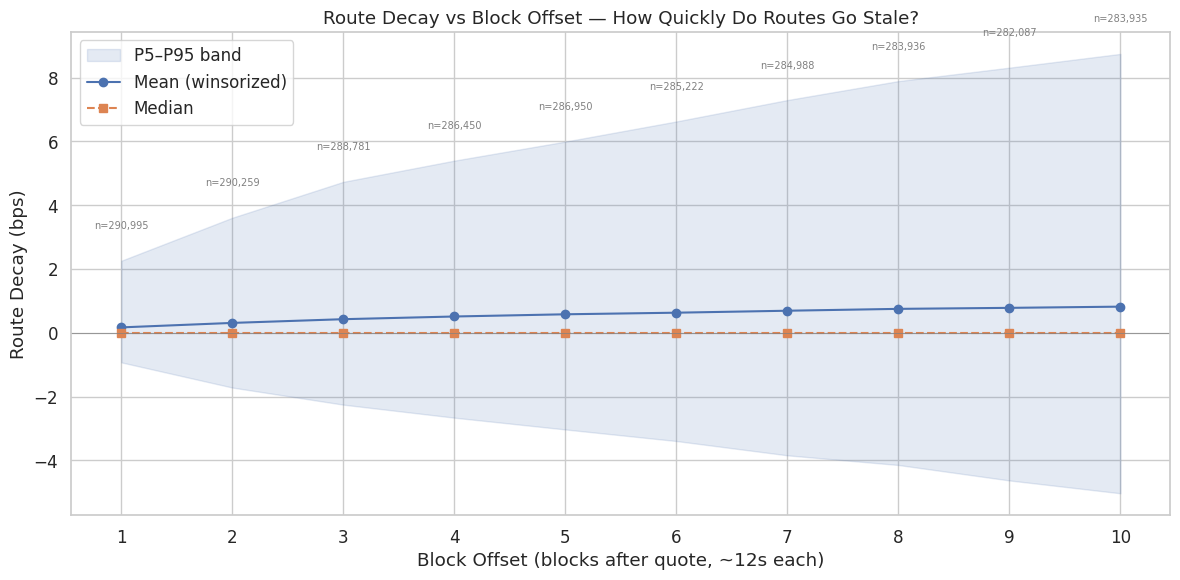

In [9]:
by_offset = (df.group_by("block_offset").agg([
    pl.col("route_decay_bps").clip(P1_CAP, P99_CAP).mean().alias("mean"),
    pl.col("route_decay_bps").median().alias("median"),
    pl.col("route_decay_bps").quantile(0.05).alias("p05"),
    pl.col("route_decay_bps").quantile(0.95).alias("p95"),
    pl.len().alias("n"),
]).sort("block_offset"))

offsets = by_offset["block_offset"].to_numpy()
means = by_offset["mean"].to_numpy()
medians = by_offset["median"].to_numpy()
p05 = by_offset["p05"].to_numpy()
p95 = by_offset["p95"].to_numpy()
ns_off = by_offset["n"].to_numpy()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.fill_between(offsets, p05, p95, alpha=0.15, color=COLORS[0], label="P5–P95 band")
ax.plot(offsets, means, "o-", color=COLORS[0], label="Mean (winsorized)")
ax.plot(offsets, medians, "s--", color=COLORS[1], label="Median")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Block Offset (blocks after quote, ~12s each)")
ax.set_ylabel("Route Decay (bps)")
ax.set_title("Route Decay vs Block Offset — How Quickly Do Routes Go Stale?")
ax.set_xticks(offsets)
for i, (o, nn) in enumerate(zip(offsets, ns_off)):
    ax.text(o, p95[i] + 1, f"n={nn:,}", ha="center", fontsize=7, color="grey")
ax.legend()
fig.tight_layout()
save(fig, "02_decay_by_offset")

Decay grows monotonically with time. But do all protocols decay at
the same rate?

## 5. Decay by Protocol

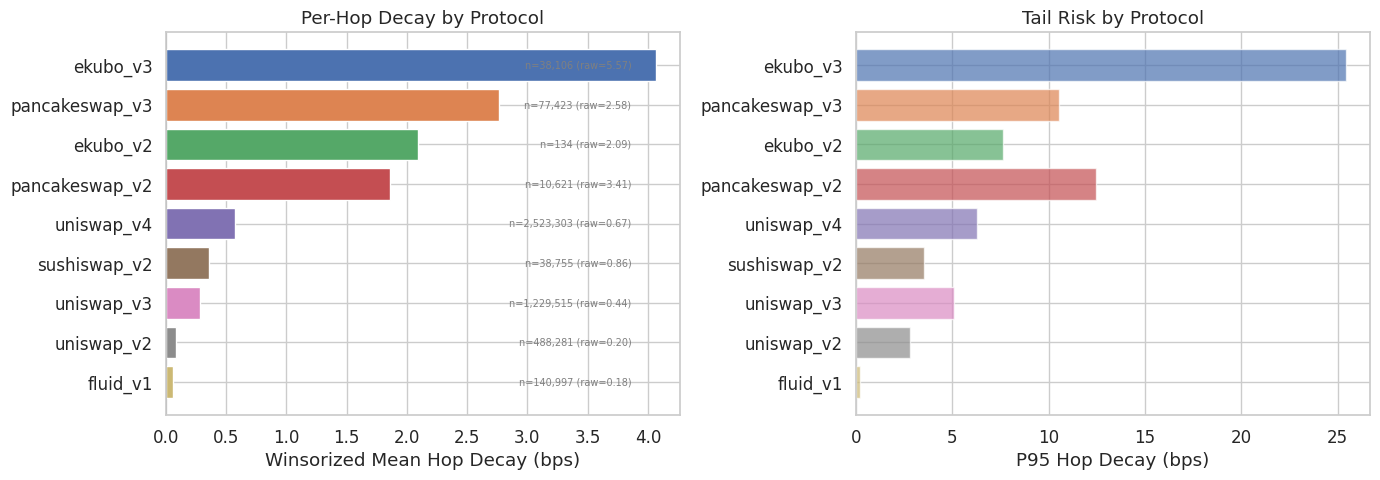

In [10]:
by_proto = (hd_full.group_by("protocol").agg([
    pl.col("hop_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean_w"),
    pl.col("hop_decay_bps").mean().alias("mean_raw"),
    pl.col("hop_decay_bps").median().alias("median"),
    pl.col("hop_decay_bps").std().alias("std"),
    pl.col("hop_decay_bps").quantile(0.95).alias("p95"),
    pl.len().alias("n"),
    pl.col("quote_id").n_unique().alias("quotes"),
]).filter(pl.col("n") > 100)
.sort("mean_w", descending=True))

protos = by_proto["protocol"].to_list()
means_w = by_proto["mean_w"].to_numpy()
means_r = by_proto["mean_raw"].to_numpy()
ns = by_proto["n"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(protos, means_w, color=COLORS[:len(protos)])
axes[0].axvline(0, color="grey", linewidth=0.5)
axes[0].set_xlabel("Winsorized Mean Hop Decay (bps)")
axes[0].set_title("Per-Hop Decay by Protocol")
axes[0].invert_yaxis()
for i, (mw, mr, n_) in enumerate(zip(means_w, means_r, ns)):
    axes[0].text(max(means_w) * 0.95, i, f"n={n_:,} (raw={mr:.2f})", va="center", ha="right", fontsize=7, color="grey")

p95s = by_proto["p95"].to_numpy()
axes[1].barh(protos, p95s, color=COLORS[:len(protos)], alpha=0.7)
axes[1].set_xlabel("P95 Hop Decay (bps)")
axes[1].set_title("Tail Risk by Protocol")
axes[1].invert_yaxis()

fig.tight_layout()
save(fig, "03_decay_by_protocol")

In [11]:
# Kruskal-Wallis test
groups = []
group_names = []
for proto in protos:
    vals = hd_full.filter(pl.col("protocol") == proto)["hop_decay_bps"].to_numpy()
    valid = vals[np.isfinite(vals)]
    if len(valid) > 100:
        groups.append(valid)
        group_names.append(proto)

if len(groups) >= 2:
    h_stat, p_val = stats.kruskal(*groups)
    print(f"Kruskal-Wallis test across {len(groups)} protocols: H={h_stat:.1f}, p={p_val:.2e}")
    if p_val < 0.001:
        print("  → Protocol differences are highly significant (p < 0.001)")

print(f"\n{'protocol':>15} {'mean_w':>8} {'mean_raw':>8} {'median':>8} {'P95':>8} {'n':>10}")
for row in by_proto.iter_rows(named=True):
    print(f"{row['protocol']:>15} {row['mean_w']:8.2f} {row['mean_raw']:8.2f} "
          f"{row['median']:8.2f} {row['p95']:8.2f} {row['n']:10,}")

Kruskal-Wallis test across 9 protocols: H=100076.4, p=0.00e+00
  → Protocol differences are highly significant (p < 0.001)

       protocol   mean_w mean_raw   median      P95          n
       ekubo_v3     4.07     5.57     0.38    25.42     38,106
 pancakeswap_v3     2.77     2.58     1.79    10.56     77,423
       ekubo_v2     2.09     2.09     0.78     7.64        134
 pancakeswap_v2     1.86     3.41     0.00    12.48     10,621
     uniswap_v4     0.58     0.67     0.00     6.30  2,523,303
   sushiswap_v2     0.36     0.86     0.00     3.54     38,755
     uniswap_v3     0.29     0.44     0.00     5.07  1,229,515
     uniswap_v2     0.08     0.20     0.00     2.83    488,281
       fluid_v1     0.06     0.18     0.00     0.23    140,997


Protocol differences are significant. Let's examine what structural
features drive these differences.

## 6. Decay by Fee Tier


NOTE: Uniswap V4 (2,523,303 hops, 55% of data) is excluded from
this analysis because fee_tier is unavailable (tycho-simulation does not yet expose V4 dynamic fees).


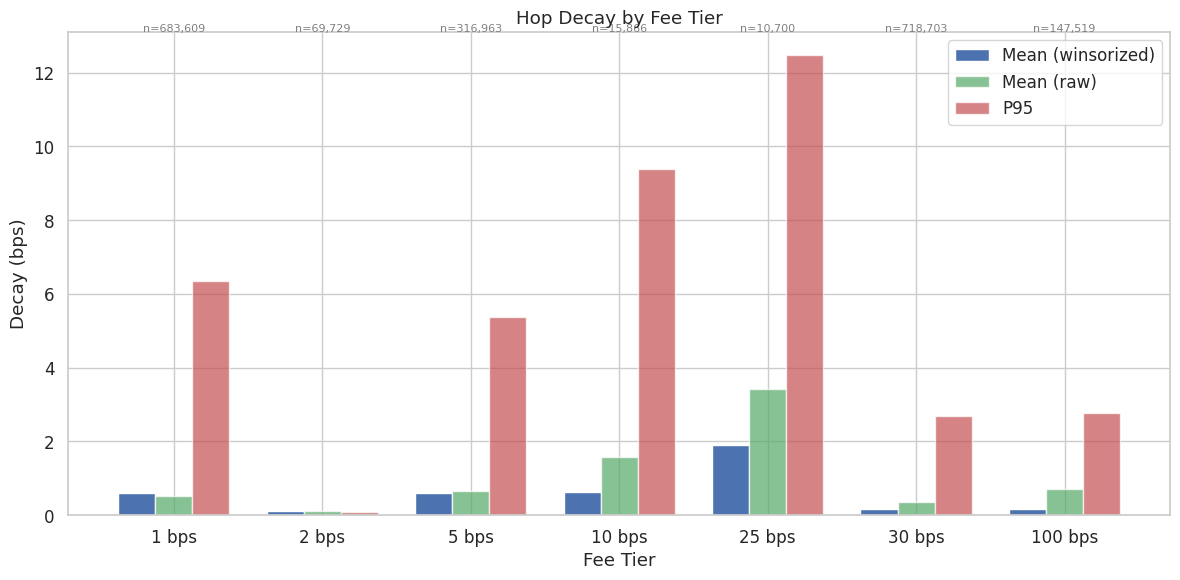

In [12]:
fee_data = (hd_full
    .filter(pl.col("fee_tier").is_not_null())
    .with_columns((pl.col("fee_tier") * 10000).round(0).cast(pl.Int32).alias("fee_bps"))
    .filter(pl.col("fee_bps") > 0))

v4_hops = hd_full.filter(pl.col("protocol") == "uniswap_v4").height
v4_fee_null = hd_full.filter((pl.col("protocol") == "uniswap_v4") & pl.col("fee_tier").is_null()).height
print(f"\nNOTE: Uniswap V4 ({v4_hops:,} hops, {100*v4_hops/hd_full.height:.0f}% of data) is excluded from")
print(f"this analysis because fee_tier is unavailable (tycho-simulation does not yet expose V4 dynamic fees).")

by_fee = (fee_data.group_by("fee_bps").agg([
    pl.col("hop_decay_bps").clip(P1_CAP, P99_CAP).mean().alias("mean"),
    pl.col("hop_decay_bps").mean().alias("mean_raw"),
    pl.col("hop_decay_bps").std().alias("std"),
    pl.col("hop_decay_bps").quantile(0.95).alias("p95"),
    pl.len().alias("n"),
]).filter(pl.col("n") > 100)
.sort("fee_bps"))

fig, ax = plt.subplots(figsize=FIGSIZE)
fees = [str(f) for f in by_fee["fee_bps"].to_list()]
means_f = by_fee["mean"].to_numpy()
means_f_raw = by_fee["mean_raw"].to_numpy()
p95_f = by_fee["p95"].to_numpy()

x = np.arange(len(fees))
w = 0.25
ax.bar(x - w, means_f, w, label="Mean (winsorized)", color=COLORS[0])
ax.bar(x, means_f_raw, w, label="Mean (raw)", color=COLORS[2], alpha=0.7)
ax.bar(x + w, p95_f, w, label="P95", color=COLORS[3], alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"{f} bps" for f in fees])
ax.set_ylabel("Decay (bps)")
ax.set_xlabel("Fee Tier")
ax.set_title("Hop Decay by Fee Tier")
ax.axhline(0, color="grey", linewidth=0.5)
ax.legend()
for i, n in enumerate(by_fee["n"].to_list()):
    ax.text(i, max(p95_f) * 1.05, f"n={n:,}", ha="center", fontsize=8, color="grey")
fig.tight_layout()
save(fig, "04_decay_by_fee_tier")

## 7. Decay by Pair Type

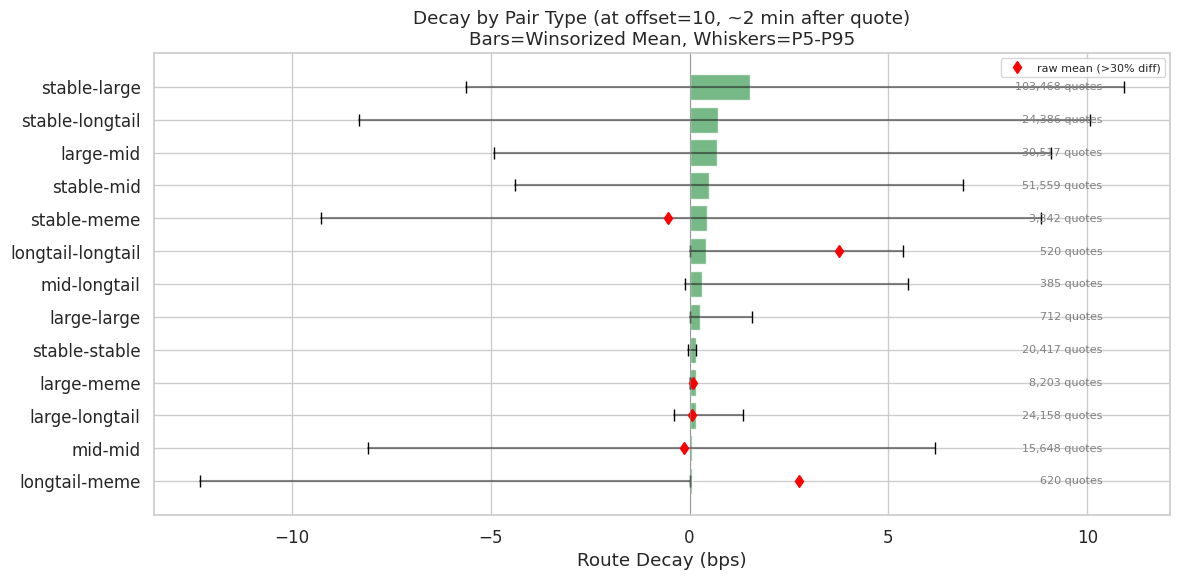

In [13]:
by_pair = (df.filter(pl.col("block_offset") == 10).group_by("pair_bucket").agg([
    pl.col("route_decay_bps").clip(P1_CAP, P99_CAP).mean().alias("mean"),
    pl.col("route_decay_bps").mean().alias("mean_raw"),
    pl.col("route_decay_bps").median().alias("median"),
    pl.col("route_decay_bps").quantile(0.05).alias("p05"),
    pl.col("route_decay_bps").quantile(0.95).alias("p95"),
    pl.col("quote_id").n_unique().alias("quotes"),
]).filter(pl.col("quotes") > 50)
.sort("mean", descending=True))

fig, ax = plt.subplots(figsize=FIGSIZE)
pairs = by_pair["pair_bucket"].to_list()
means_bp = by_pair["mean"].to_numpy()
means_bp_raw = by_pair["mean_raw"].to_numpy()
p05_bp = by_pair["p05"].to_numpy()
p95_bp = by_pair["p95"].to_numpy()

y = np.arange(len(pairs))
ax.barh(y, means_bp, color=[COLORS[2] if m >= 0 else COLORS[3] for m in means_bp], alpha=0.8)
for i in range(len(pairs)):
    ax.plot([p05_bp[i], p95_bp[i]], [y[i], y[i]], "k-", linewidth=1.5, alpha=0.5)
    ax.plot(p05_bp[i], y[i], "|", color="black", markersize=8)
    ax.plot(p95_bp[i], y[i], "|", color="black", markersize=8)
    # Annotate raw mean when it differs by >30% from winsorized
    if means_bp[i] != 0 and abs(means_bp_raw[i] - means_bp[i]) / abs(means_bp[i]) > 0.3:
        ax.plot(means_bp_raw[i], y[i], "d", color="red", markersize=6)
if any(means_bp[i] != 0 and abs(means_bp_raw[i] - means_bp[i]) / abs(means_bp[i]) > 0.3
       for i in range(len(pairs))):
    ax.plot([], [], "d", color="red", markersize=6, label="raw mean (>30% diff)")
    ax.legend(fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(pairs)
ax.set_xlabel("Route Decay (bps)")
ax.set_title("Decay by Pair Type (at offset=10, ~2 min after quote)\nBars=Winsorized Mean, Whiskers=P5-P95")
ax.axvline(0, color="grey", linewidth=0.5)
ax.invert_yaxis()
for i, q in enumerate(by_pair["quotes"].to_list()):
    ax.text(max(p95_bp) * 0.95, i, f"{q:,} quotes", va="center", ha="right", fontsize=8, color="grey")
fig.tight_layout()
save(fig, "05_decay_by_pair_type")

## 8. Market Movement vs Execution Slippage (100% Fill Rate)

Decomposition fill rate: 2,862,216/2,863,603 (100.0%)
Mean decay (all data):       0.626 bps
Mean decay (decomp subset):  0.626 bps
  ✓ Decomp subset is representative (bias=0.000 bps)


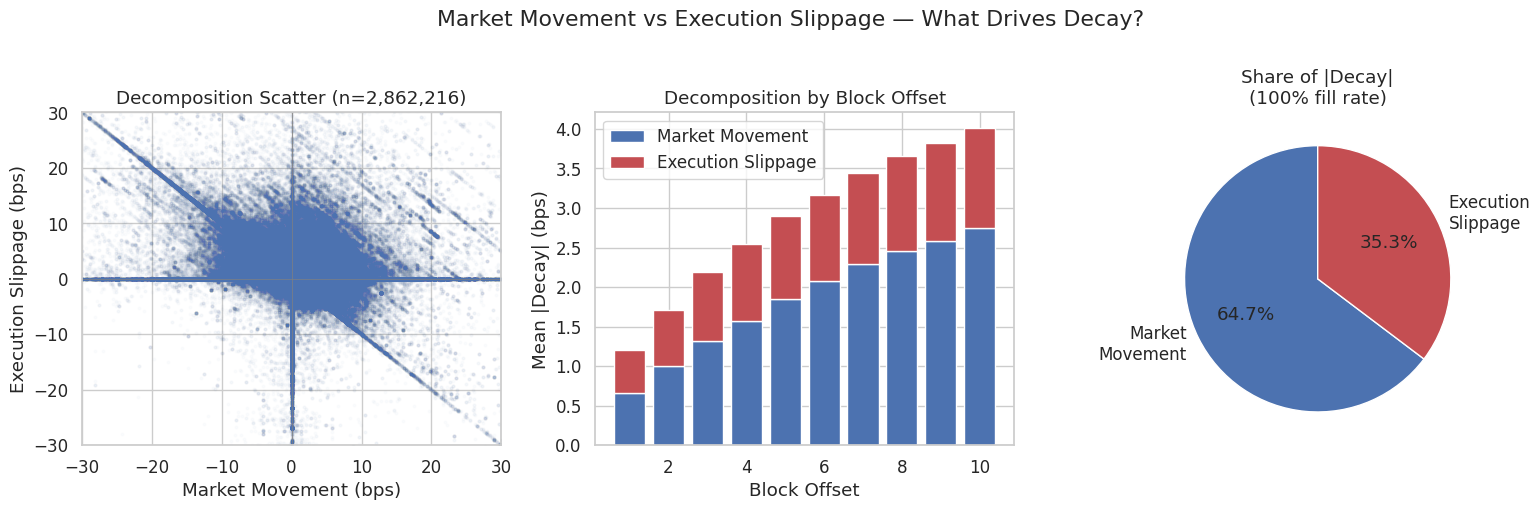


--- Decomposition Statistics ---
Mean |market_movement|: 1.849 bps
Mean |execution_slippage|: 1.008 bps
Market movement share: 64.7%
Execution slippage share: 35.3%


In [14]:
decomp = df.filter(pl.col("market_movement_bps").is_not_null())
all_mean = df["route_decay_bps"].mean()
decomp_mean = decomp["route_decay_bps"].mean()
fill_pct = 100 * decomp.height / df.height
print(f"Decomposition fill rate: {decomp.height:,}/{df.height:,} ({fill_pct:.1f}%)")
print(f"Mean decay (all data):       {all_mean:.3f} bps")
print(f"Mean decay (decomp subset):  {decomp_mean:.3f} bps")
bias = abs(decomp_mean - all_mean)
if bias > 1:
    print(f"  ⚠ Decomposed subset differs by {bias:.2f} bps — possible selection bias.")
else:
    print(f"  ✓ Decomp subset is representative (bias={bias:.3f} bps)")

if decomp.height > 100:
    mm = decomp["market_movement_bps"].to_numpy()
    es = decomp["execution_slippage_bps"].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].scatter(mm, es, alpha=0.02, s=3, color=COLORS[0])
    axes[0].axhline(0, color="grey", linewidth=0.5)
    axes[0].axvline(0, color="grey", linewidth=0.5)
    axes[0].set_xlabel("Market Movement (bps)")
    axes[0].set_ylabel("Execution Slippage (bps)")
    axes[0].set_title(f"Decomposition Scatter (n={len(mm):,})")
    axes[0].set_xlim(-30, 30)
    axes[0].set_ylim(-30, 30)

    decomp_off = (decomp.group_by("block_offset").agg([
        pl.col("market_movement_bps").abs().mean().alias("mm_abs"),
        pl.col("execution_slippage_bps").abs().mean().alias("es_abs"),
    ]).sort("block_offset"))
    off = decomp_off["block_offset"].to_numpy()
    mm_abs = decomp_off["mm_abs"].to_numpy()
    es_abs = decomp_off["es_abs"].to_numpy()

    axes[1].bar(off, mm_abs, label="Market Movement", color=COLORS[0])
    axes[1].bar(off, es_abs, bottom=mm_abs, label="Execution Slippage", color=COLORS[3])
    axes[1].set_xlabel("Block Offset")
    axes[1].set_ylabel("Mean |Decay| (bps)")
    axes[1].set_title("Decomposition by Block Offset")
    axes[1].legend()

    total_mm = np.abs(mm).sum()
    total_es = np.abs(es).sum()
    axes[2].pie([total_mm, total_es],
                labels=["Market\nMovement", "Execution\nSlippage"],
                autopct="%1.1f%%",
                colors=[COLORS[0], COLORS[3]],
                startangle=90)
    axes[2].set_title(f"Share of |Decay|\n({fill_pct:.0f}% fill rate)")

    fig.suptitle("Market Movement vs Execution Slippage — What Drives Decay?", y=1.02)
    fig.tight_layout()
    save(fig, "06_decomposition")

    # Decomposition stats
    print(f"\n--- Decomposition Statistics ---")
    print(f"Mean |market_movement|: {np.abs(mm).mean():.3f} bps")
    print(f"Mean |execution_slippage|: {np.abs(es).mean():.3f} bps")
    mm_share = 100 * total_mm / (total_mm + total_es)
    print(f"Market movement share: {mm_share:.1f}%")
    print(f"Execution slippage share: {100-mm_share:.1f}%")

With the decomposition established, let's examine which structural
features correlate with higher decay.

## 9. Pool Depth vs Decay

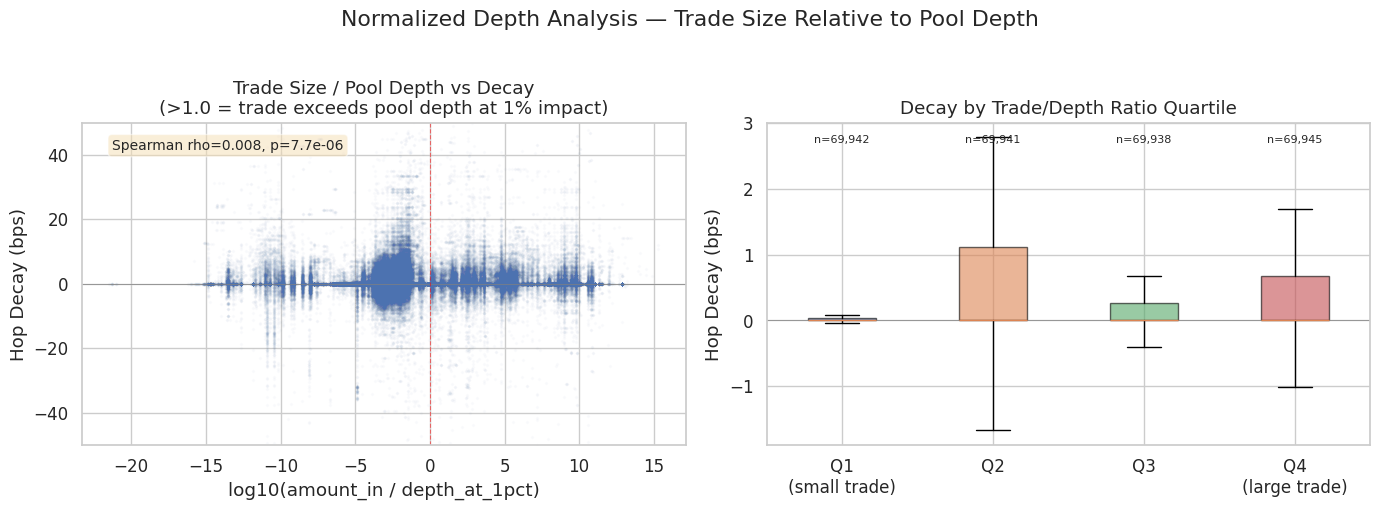

In [15]:
hd5 = hd_full.filter(pl.col("block_offset") == 5)

# Join hop decay with route-level amount_in for normalization
hd5_with_amount = hd5.join(
    df.filter(pl.col("block_offset") == 5).select(["quote_id", "solver_id", "amount_in"]),
    on=["quote_id", "solver_id"], how="left"
)

depth_df = (hd5_with_amount
    .filter(pl.col("depth_at_1pct").is_not_null())
    .with_columns([
        pl.col("depth_at_1pct").cast(pl.Float64, strict=False).alias("depth_f64"),
        pl.col("amount_in").cast(pl.Float64, strict=False).alias("amount_f64"),
    ])
    .filter(pl.col("depth_f64").is_not_null() & (pl.col("depth_f64") > 0))
    .filter(pl.col("amount_f64").is_not_null() & (pl.col("amount_f64") > 0))
    .with_columns(
        (pl.col("amount_f64") / pl.col("depth_f64")).alias("trade_depth_ratio")
    ))

if depth_df.height > 500:
    log_ratio = np.log10(depth_df["trade_depth_ratio"].to_numpy())
    decay_d = depth_df["hop_decay_bps"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Normalized trade-size / depth ratio scatter
    valid_r = np.isfinite(log_ratio) & np.isfinite(decay_d)
    axes[0].scatter(log_ratio[valid_r], decay_d[valid_r], alpha=0.02, s=2, color=COLORS[0])
    axes[0].set_xlabel("log10(amount_in / depth_at_1pct)")
    axes[0].set_ylabel("Hop Decay (bps)")
    axes[0].set_title("Trade Size / Pool Depth vs Decay\n(>1.0 = trade exceeds pool depth at 1% impact)")
    axes[0].set_ylim(-50, 50)
    axes[0].axhline(0, color="grey", linewidth=0.5)
    axes[0].axvline(0, color="red", linestyle="--", alpha=0.5, linewidth=0.8)

    rho, pval = stats.spearmanr(log_ratio[valid_r], decay_d[valid_r])
    axes[0].text(0.05, 0.95, f"Spearman rho={rho:.3f}, p={pval:.1e}",
                 transform=axes[0].transAxes, fontsize=10, va="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    # Panel 2: Depth quartile boxplot (using normalized ratio)
    q25, q50, q75 = np.percentile(log_ratio[valid_r], [25, 50, 75])
    groups_depth = []
    tick_labels = []
    for label, lo, hi in [("Q1\n(small trade)", -np.inf, q25), ("Q2", q25, q50),
                           ("Q3", q50, q75), ("Q4\n(large trade)", q75, np.inf)]:
        mask = (log_ratio >= lo) & (log_ratio < hi)
        groups_depth.append(decay_d[mask])
        tick_labels.append(label)

    bp = axes[1].boxplot(groups_depth, tick_labels=tick_labels, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], COLORS[:4]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[1].set_ylabel("Hop Decay (bps)")
    axes[1].set_title("Decay by Trade/Depth Ratio Quartile")
    axes[1].axhline(0, color="grey", linewidth=0.5)
    for i, g in enumerate(groups_depth):
        axes[1].text(i + 1, axes[1].get_ylim()[1] * 0.9, f"n={len(g):,}", ha="center", fontsize=8)

    fig.suptitle("Normalized Depth Analysis — Trade Size Relative to Pool Depth", y=1.02)
    fig.tight_layout()
    save(fig, "07_depth_vs_decay")

## 10. Hop Count Analysis

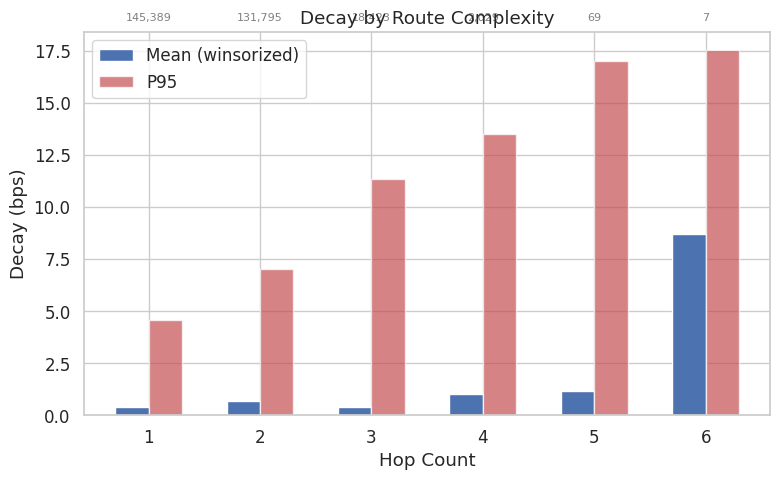

In [16]:
by_hops = (df.group_by("hop_count").agg([
    pl.col("route_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean"),
    pl.col("route_decay_bps").std().alias("std"),
    pl.col("route_decay_bps").quantile(0.95).alias("p95"),
    pl.col("quote_id").n_unique().alias("quotes"),
]).sort("hop_count"))

fig, ax = plt.subplots(figsize=(8, 5))
hops = by_hops["hop_count"].to_numpy()
means_h = by_hops["mean"].to_numpy()
p95_h = by_hops["p95"].to_numpy()
quotes_h = by_hops["quotes"].to_numpy()

ax.bar(hops - 0.15, means_h, 0.3, label="Mean (winsorized)", color=COLORS[0])
ax.bar(hops + 0.15, p95_h, 0.3, label="P95", color=COLORS[3], alpha=0.7)
ax.set_xlabel("Hop Count")
ax.set_ylabel("Decay (bps)")
ax.set_title("Decay by Route Complexity")
ax.legend()
ax.axhline(0, color="grey", linewidth=0.5)
for i, (h, q) in enumerate(zip(hops, quotes_h)):
    ax.text(h, max(p95_h) * 1.08, f"{q:,}", ha="center", fontsize=8, color="grey")
fig.tight_layout()
save(fig, "08_decay_by_hop_count")

## 11. Worst Pools

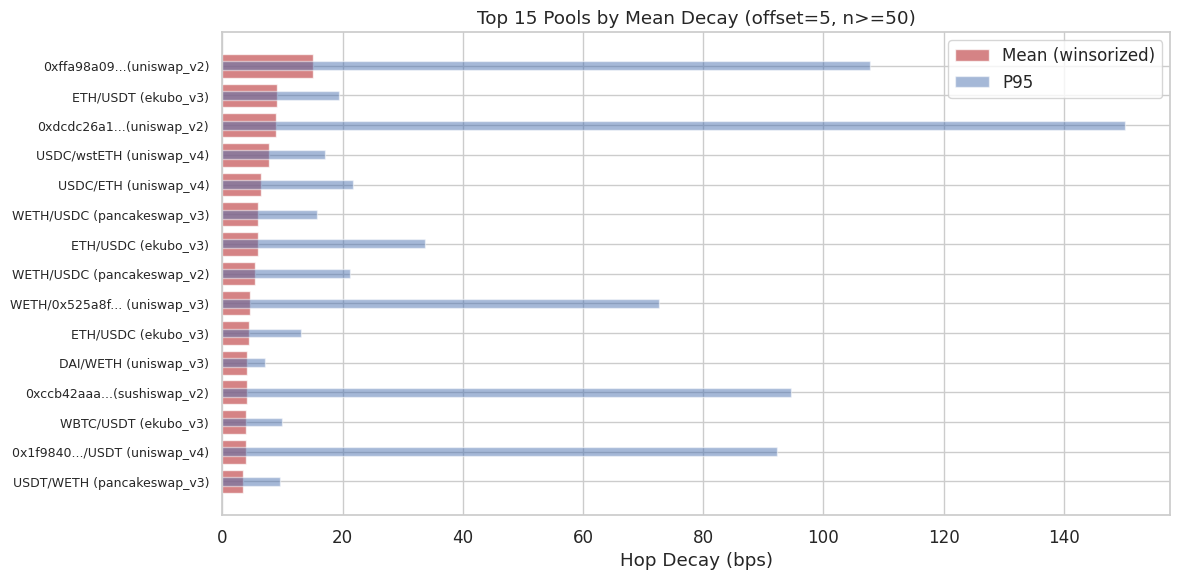


--- Top 15 pools by mean decay ---
                     pair        protocol   mean_w mean_raw      P95      n
0xffa98a09...(uniswap_v2)      uniswap_v2    15.09    44.11   107.80     64
                 ETH/USDT        ekubo_v3     9.08     9.79    19.42    234
0xdcdc26a1...(uniswap_v2)      uniswap_v2     8.96    28.03   150.22     64
              USDC/wstETH      uniswap_v4     7.76     7.84    17.02     74
                 USDC/ETH      uniswap_v4     6.48     7.27    21.74    433
                WETH/USDC  pancakeswap_v3     5.93     6.05    15.74    335
                 ETH/USDC        ekubo_v3     5.93     9.03    33.77  1,767
                WETH/USDC  pancakeswap_v2     5.40     6.05    21.28    184
         WETH/0x525a8f...      uniswap_v3     4.58    11.07    72.63     62
                 ETH/USDC        ekubo_v3     4.41     4.49    13.13    478
                 DAI/WETH      uniswap_v3     4.14     4.14     7.05    147
0xccb42aaa...(sushiswap_v2)    sushiswap_v2     4.07

In [17]:
import json as _json

by_pool = (hd5
    .group_by(["component_id", "protocol"]).agg([
        pl.col("hop_decay_bps").clip(P1_CAP, P99_CAP).mean().alias("mean"),
        pl.col("hop_decay_bps").mean().alias("mean_raw"),
        pl.col("hop_decay_bps").std().alias("std"),
        pl.col("hop_decay_bps").quantile(0.95).alias("p95"),
        pl.len().alias("n"),
    ]).filter(pl.col("n") >= 50)
    .sort("mean", descending=True))

# Extract token pair names from route_json for labeling
_pool_tokens = {}
_ql_sample = df.filter(pl.col("block_offset") == 1).head(50_000)
if "route_json" not in _ql_sample.columns:
    _ql_files = sorted(DATA_DIR.glob("quote_log_*.parquet"))[:200]
    if _ql_files:
        _ql_raw = pl.concat([pl.read_parquet(f) for f in _ql_files])
        for row in _ql_raw.iter_rows(named=True):
            for swap in _json.loads(row.get("route_json", "{}")).get("swaps", []):
                cid = swap.get("component_id", "")
                if cid and cid not in _pool_tokens:
                    _pool_tokens[cid] = (swap.get("token_in", ""), swap.get("token_out", ""))

_TOKEN_NAMES = {
    "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2": "WETH",
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": "USDC",
    "0xdac17f958d2ee523a2206206994597c13d831ec7": "USDT",
    "0x2260fac5e5542a773aa44fbcfedf7c193bc2c599": "WBTC",
    "0x6b175474e89094c44da98b954eedeac495271d0f": "DAI",
    "0x7f39c581f595b53c5cb19bd0b3f8da6c935e2ca0": "wstETH",
    "0xcbb7c0000ab88b473b1f5afd9ef808440eed33bf": "cbBTC",
    "0x0000000000000000000000000000000000000000": "ETH",
    "0x4200000000000000000000000000000000000006": "WETH",
}

def _token_name(addr):
    return _TOKEN_NAMES.get(addr.lower(), addr[:8] + "...")

def _pool_label(component_id, protocol):
    tokens = _pool_tokens.get(component_id)
    if tokens:
        return f"{_token_name(tokens[0])}/{_token_name(tokens[1])} ({protocol})"
    return f"{component_id[:10]}...({protocol})"

fig, ax = plt.subplots(figsize=(12, 6))
top15 = by_pool.head(15)
pool_labels = [_pool_label(r["component_id"], r["protocol"]) for r in top15.iter_rows(named=True)]
means_pool = top15["mean"].to_numpy()
p95_pool = top15["p95"].to_numpy()

y = np.arange(len(pool_labels))
ax.barh(y, means_pool, color=COLORS[3], alpha=0.7, label="Mean (winsorized)")
ax.barh(y, p95_pool, height=0.3, color=COLORS[0], alpha=0.5, label="P95")
ax.set_yticks(y)
ax.set_yticklabels(pool_labels, fontsize=9)
ax.set_xlabel("Hop Decay (bps)")
ax.set_title("Top 15 Pools by Mean Decay (offset=5, n>=50)")
ax.legend()
ax.invert_yaxis()
fig.tight_layout()
save(fig, "09_worst_pools")

print("\n--- Top 15 pools by mean decay ---")
print(f"{'pair':>25} {'protocol':>15} {'mean_w':>8} {'mean_raw':>8} {'P95':>8} {'n':>6}")
for row in top15.iter_rows(named=True):
    label = _pool_label(row["component_id"], row["protocol"])
    pair = label.split(" (")[0]
    print(f"{pair:>25} {row['protocol']:>15} {row['mean']:8.2f} {row['mean_raw']:8.2f} {row['p95']:8.2f} {row['n']:6,}")

## 12. Temporal Stability & Time-of-Day

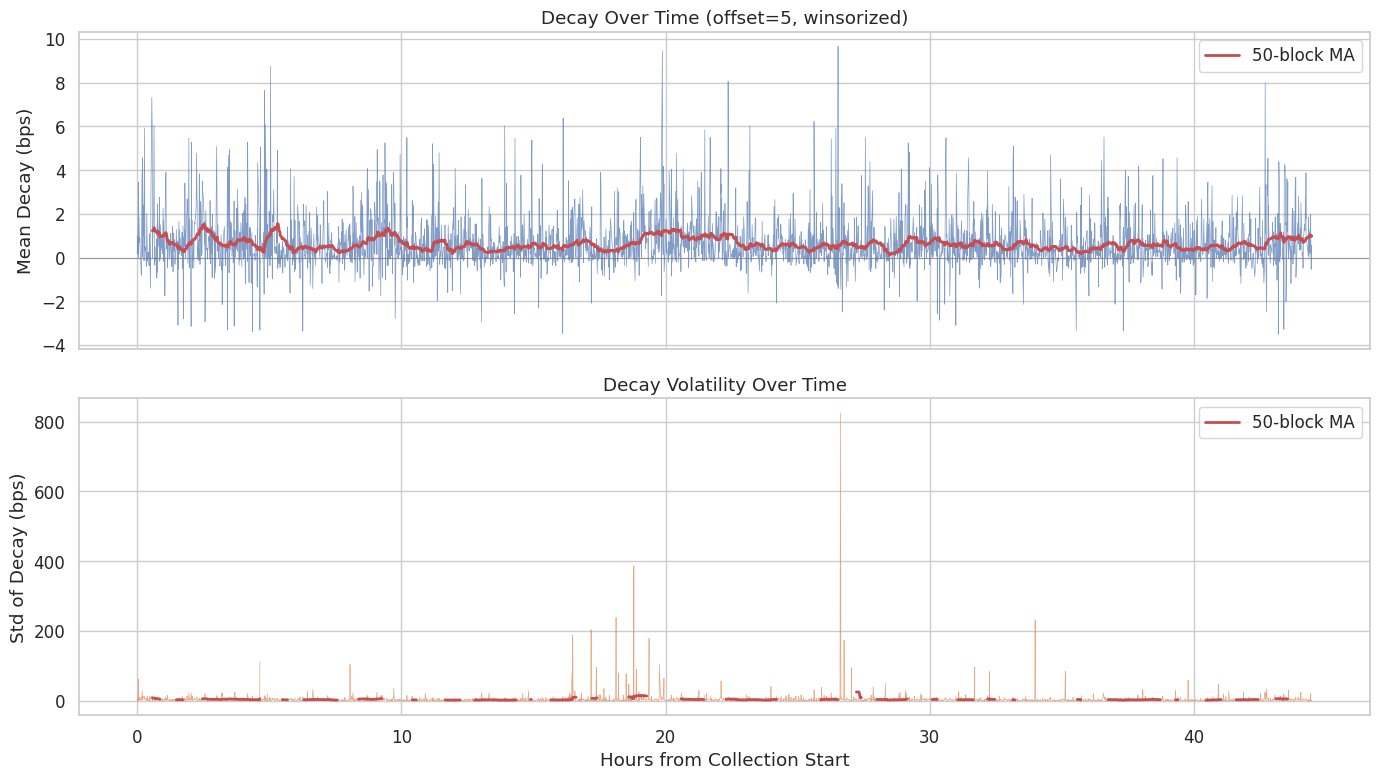

In [18]:
temporal = (df.filter(pl.col("block_offset") == 5)
    .group_by("block_number").agg([
        pl.col("route_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean_decay"),
        pl.col("route_decay_bps").std().alias("std_decay"),
        pl.len().alias("n"),
    ]).sort("block_number"))

if temporal.height > 20:
    block_nums = temporal["block_number"].to_numpy()
    means_t = temporal["mean_decay"].to_numpy()
    stds_t = temporal["std_decay"].to_numpy()
    hours = (block_nums - block_nums.min()) * 12 / 3600

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(hours, means_t, linewidth=0.5, alpha=0.7, color=COLORS[0])
    window = min(50, len(means_t) // 5)
    if window > 1:
        rolling = np.convolve(means_t, np.ones(window)/window, mode="valid")
        axes[0].plot(hours[window-1:], rolling, linewidth=2, color=COLORS[3], label=f"{window}-block MA")
    axes[0].axhline(0, color="grey", linewidth=0.5)
    axes[0].set_ylabel("Mean Decay (bps)")
    axes[0].set_title("Decay Over Time (offset=5, winsorized)")
    axes[0].legend()

    axes[1].plot(hours, stds_t, linewidth=0.5, alpha=0.7, color=COLORS[1])
    if window > 1:
        rolling_s = np.convolve(stds_t, np.ones(window)/window, mode="valid")
        axes[1].plot(hours[window-1:], rolling_s, linewidth=2, color=COLORS[3], label=f"{window}-block MA")
    axes[1].set_ylabel("Std of Decay (bps)")
    axes[1].set_xlabel("Hours from Collection Start")
    axes[1].set_title("Decay Volatility Over Time")
    axes[1].legend()
    fig.tight_layout()
    save(fig, "10_temporal_stability")

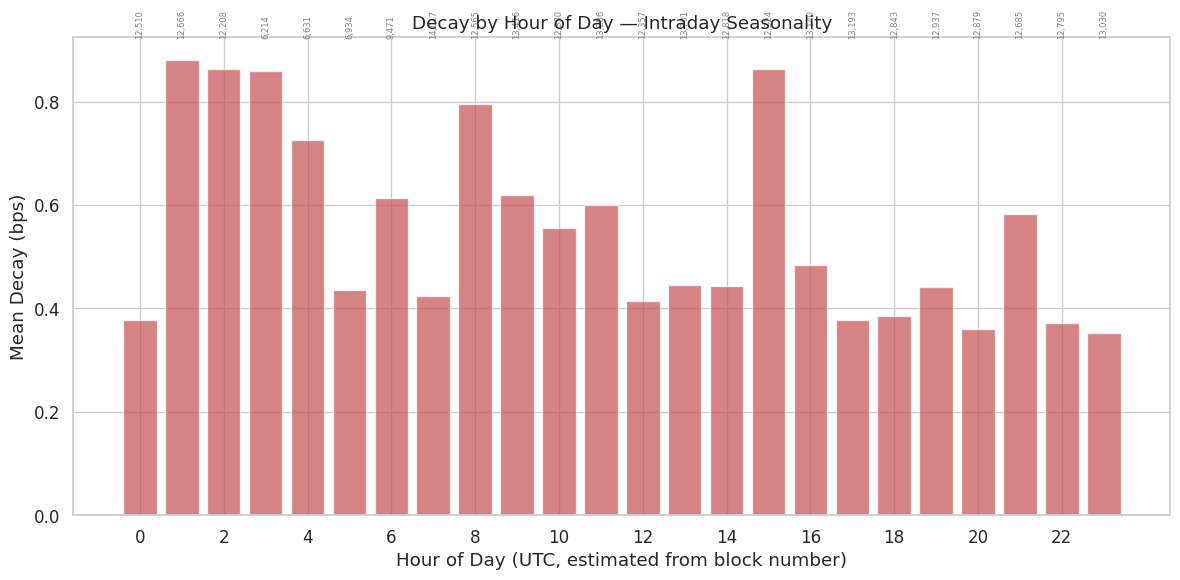

In [19]:
# Time-of-day analysis
hour_data = df.filter(
    pl.col("block_offset") == 5
).filter(pl.col("hour_of_day").is_not_null())

if hour_data.height > 1000:
    by_hour = (hour_data.group_by("hour_of_day").agg([
        pl.col("route_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean"),
        pl.col("route_decay_bps").std().alias("std"),
        pl.len().alias("n"),
    ]).sort("hour_of_day"))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    h = by_hour["hour_of_day"].to_numpy()
    m = by_hour["mean"].to_numpy()
    n_h = by_hour["n"].to_numpy()

    ax.bar(h, m, color=[COLORS[3] if v > 0 else COLORS[0] for v in m], alpha=0.7)
    ax.set_xlabel("Hour of Day (UTC, estimated from block number)")
    ax.set_ylabel("Mean Decay (bps)")
    ax.set_title("Decay by Hour of Day — Intraday Seasonality")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xticks(range(0, 24, 2))
    for i, (hh, nn) in enumerate(zip(h, n_h)):
        ax.text(hh, max(m) * 1.05, f"{nn:,}", ha="center", fontsize=6, rotation=90, color="grey")
    fig.tight_layout()
    save(fig, "10b_decay_by_hour")

## 13. Feature Correlations

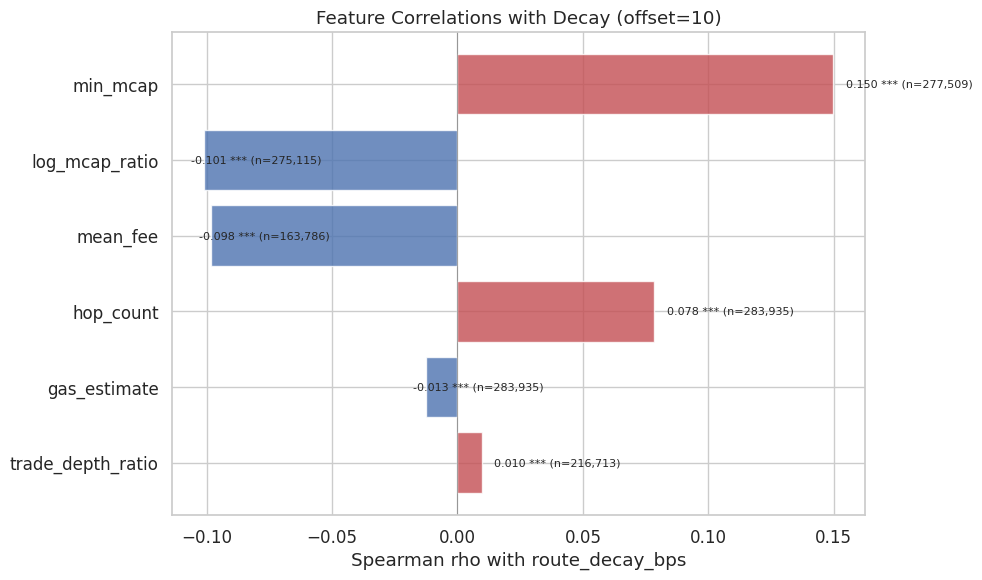

In [20]:
df10 = df.filter(pl.col("block_offset") == 10)
target = df10["route_decay_bps"].to_numpy()

feature_specs = [
    ("hop_count", df10["hop_count"].cast(pl.Float64).to_numpy(), None),
    ("gas_estimate", df10["gas_estimate"].cast(pl.Float64).to_numpy(), None),
]
for col in ["min_mcap", "log_mcap_ratio"]:
    vals = df10[col]
    if vals.drop_nulls().len() > 200:
        mask = vals.is_not_null().to_numpy()
        feature_specs.append((col, vals.to_numpy(), mask))

# Add hop-level features aggregated to route level
# mean_fee: average fee tier across hops (excludes V4 which has null fee)
fee_agg = (hd_full.filter(pl.col("block_offset") == 10)
    .filter(pl.col("fee_tier").is_not_null())
    .group_by(["quote_id", "solver_id"]).agg([
        pl.col("fee_tier").mean().alias("mean_fee"),
    ]))
joined_fee = df10.join(fee_agg, on=["quote_id", "solver_id"], how="left")
vals_fee = joined_fee["mean_fee"]
if vals_fee.drop_nulls().len() > 200:
    mask = vals_fee.is_not_null().to_numpy()
    feature_specs.append(("mean_fee", vals_fee.to_numpy(), mask))

# trade_depth_ratio: amount_in / depth_at_1pct (normalized, comparable across tokens)
depth_agg = (hd_full.filter(pl.col("block_offset") == 10)
    .filter(pl.col("depth_at_1pct").is_not_null())
    .join(
        df10.select(["quote_id", "solver_id", "amount_in"]),
        on=["quote_id", "solver_id"], how="left"
    )
    .with_columns([
        pl.col("depth_at_1pct").cast(pl.Float64, strict=False).alias("_depth"),
        pl.col("amount_in").cast(pl.Float64, strict=False).alias("_amount"),
    ])
    .filter(pl.col("_depth").is_not_null() & (pl.col("_depth") > 0))
    .filter(pl.col("_amount").is_not_null() & (pl.col("_amount") > 0))
    .with_columns((pl.col("_amount") / pl.col("_depth")).alias("trade_depth_ratio"))
    .group_by(["quote_id", "solver_id"]).agg([
        pl.col("trade_depth_ratio").mean().alias("mean_trade_depth_ratio"),
    ]))
joined_depth = df10.join(depth_agg, on=["quote_id", "solver_id"], how="left")
vals_depth = joined_depth["mean_trade_depth_ratio"]
if vals_depth.drop_nulls().len() > 200:
    mask = vals_depth.is_not_null().to_numpy()
    feature_specs.append(("trade_depth_ratio", vals_depth.to_numpy(), mask))

results = []
for name, vals, mask in feature_specs:
    if mask is not None:
        valid = mask & np.isfinite(vals) & np.isfinite(target)
    else:
        valid = np.isfinite(vals) & np.isfinite(target)
    if valid.sum() < 100:
        continue
    rho, pval = stats.spearmanr(vals[valid], target[valid])
    results.append((name, rho, pval, valid.sum()))

results.sort(key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(10, 6))
names = [r[0] for r in results]
rhos = [r[1] for r in results]
pvals_r = [r[2] for r in results]
ns_r = [r[3] for r in results]

colors = [COLORS[3] if r > 0 else COLORS[0] for r in rhos]
ax.barh(names, rhos, color=colors, alpha=0.8)
ax.set_xlabel("Spearman rho with route_decay_bps")
ax.set_title("Feature Correlations with Decay (offset=10)")
ax.axvline(0, color="grey", linewidth=0.5)
for i, (r, p, nn) in enumerate(zip(rhos, pvals_r, ns_r)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    ax.text(r + 0.005 * np.sign(r), i, f"{r:.3f} {sig} (n={nn:,})", va="center", fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
save(fig, "11_feature_correlations")

## 14. Decay Heatmap: Protocol x Fee Tier

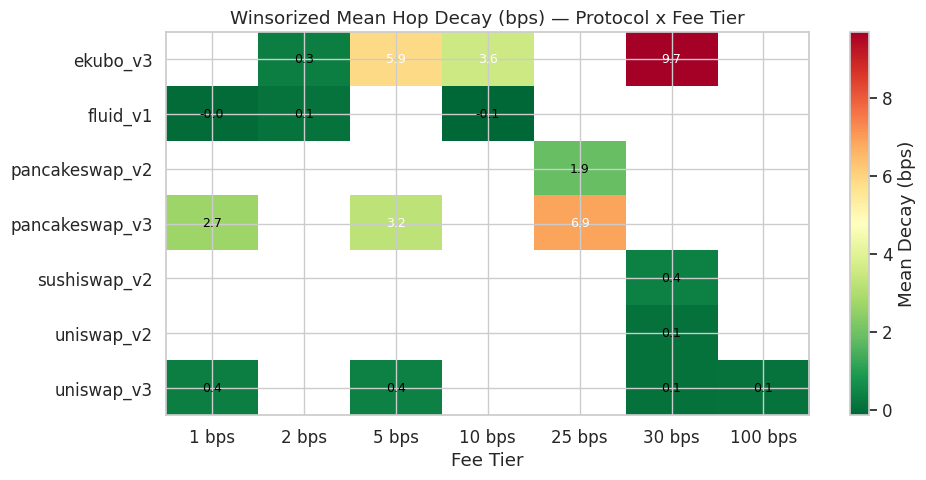

In [21]:
heatmap_data = (hd_full
    .filter(pl.col("fee_tier").is_not_null() & pl.col("protocol").is_not_null())
    .with_columns((pl.col("fee_tier") * 10000).round(0).cast(pl.Int32).alias("fee_bps"))
    .filter(pl.col("fee_bps") > 0)
    .group_by(["protocol", "fee_bps"]).agg([
        pl.col("hop_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean_decay"),
        pl.len().alias("n"),
    ]).filter(pl.col("n") >= 50))

if heatmap_data.height > 3:
    pivot = heatmap_data.pivot(on="fee_bps", index="protocol", values="mean_decay").sort("protocol")
    protos_hm = pivot["protocol"].to_list()
    fee_cols = [c for c in pivot.columns if c != "protocol"]
    fee_cols = sorted(fee_cols, key=lambda x: int(x))
    matrix = pivot.select(fee_cols).to_numpy()

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(fee_cols)))
    ax.set_xticklabels([f"{c} bps" for c in fee_cols])
    ax.set_yticks(range(len(protos_hm)))
    ax.set_yticklabels(protos_hm)
    ax.set_xlabel("Fee Tier")
    ax.set_title("Winsorized Mean Hop Decay (bps) — Protocol x Fee Tier")

    for i in range(len(protos_hm)):
        for j in range(len(fee_cols)):
            val = matrix[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9,
                        color="white" if abs(val) > 3 else "black")

    plt.colorbar(im, ax=ax, label="Mean Decay (bps)")
    fig.tight_layout()
    save(fig, "12_heatmap_protocol_fee")

## 15. High-Decay Route Analysis

Routes with >20 bps decay at offset=10: 3,066 / 283,935 (1.08%)


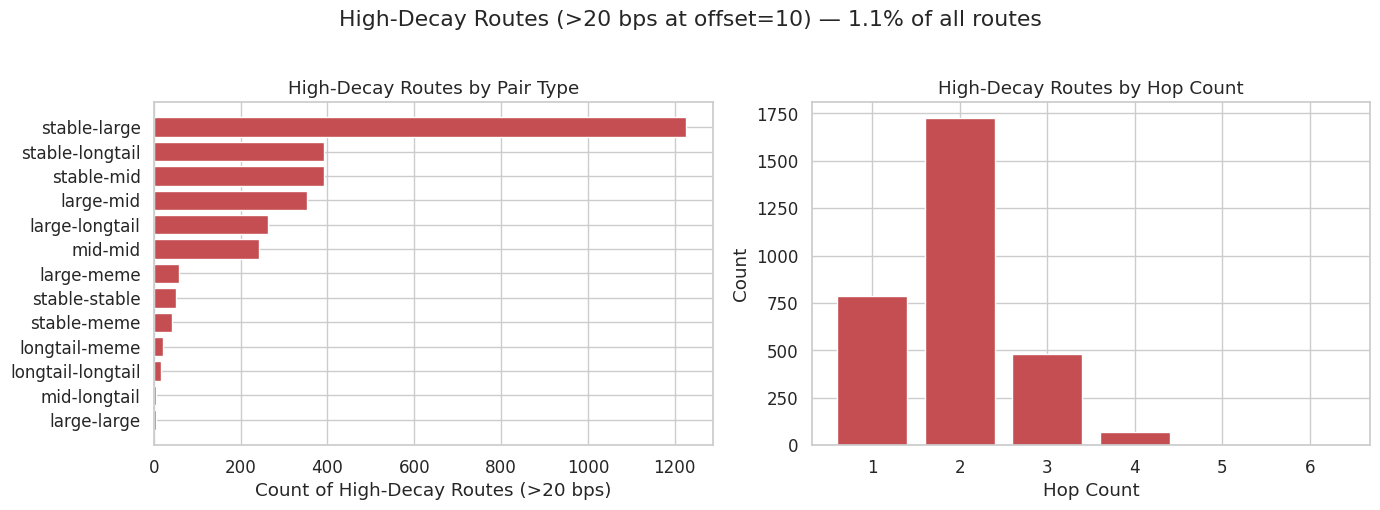

In [22]:
high_decay = df10.filter(pl.col("route_decay_bps") > 20)
total_10 = df10.height
pct_high = 100 * high_decay.height / total_10

print(f"Routes with >20 bps decay at offset=10: {high_decay.height:,} / {total_10:,} ({pct_high:.2f}%)")

if high_decay.height > 10:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    high_pairs = high_decay["pair_bucket"].value_counts().sort("count", descending=True)
    axes[0].barh(high_pairs["pair_bucket"].to_list(), high_pairs["count"].to_list(), color=COLORS[3])
    axes[0].set_xlabel("Count of High-Decay Routes (>20 bps)")
    axes[0].set_title("High-Decay Routes by Pair Type")
    axes[0].invert_yaxis()

    high_hops = high_decay["hop_count"].value_counts().sort("hop_count")
    axes[1].bar(high_hops["hop_count"].to_list(), high_hops["count"].to_list(), color=COLORS[3])
    axes[1].set_xlabel("Hop Count")
    axes[1].set_ylabel("Count")
    axes[1].set_title("High-Decay Routes by Hop Count")

    fig.suptitle(f"High-Decay Routes (>20 bps at offset=10) — {pct_high:.1f}% of all routes", y=1.02)
    fig.tight_layout()
    save(fig, "13_high_decay_analysis")

## 16. Day-of-Week Analysis

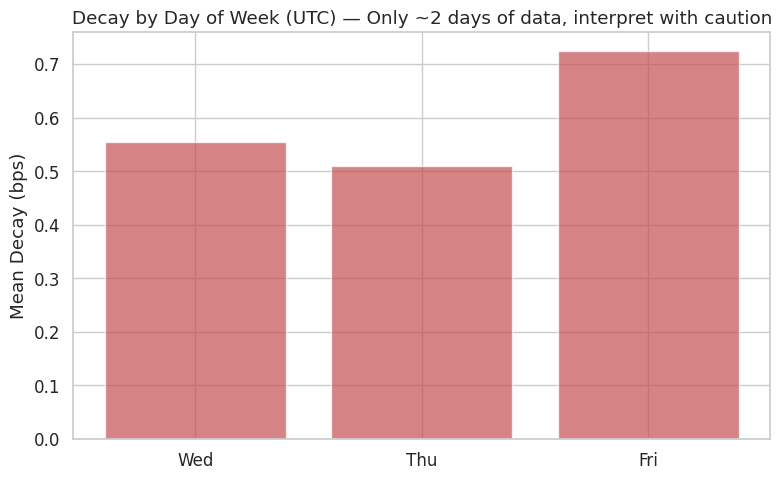

In [23]:
dow_data = df.filter(
    pl.col("block_offset") == 5
).filter(pl.col("day_of_week").is_not_null())

if dow_data.height > 1000:
    by_dow = (dow_data.group_by("day_of_week").agg([
        pl.col("route_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean"),
        pl.col("route_decay_bps").std().alias("std"),
        pl.len().alias("n"),
    ]).sort("day_of_week"))

    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    fig, ax = plt.subplots(figsize=(8, 5))
    d = by_dow["day_of_week"].to_numpy()
    m = by_dow["mean"].to_numpy()
    labels = [day_names[int(dd)] if int(dd) < 7 else str(dd) for dd in d]

    ax.bar(labels, m, color=[COLORS[3] if v > 0 else COLORS[0] for v in m], alpha=0.7)
    ax.set_ylabel("Mean Decay (bps)")
    ax.set_title("Decay by Day of Week (UTC) — Only ~2 days of data, interpret with caution")
    ax.axhline(0, color="grey", linewidth=0.5)
    fig.tight_layout()
    save(fig, "14_decay_by_day_of_week")

## 17. Split Route Analysis

In [24]:
split_data = df.filter(pl.col("block_offset") == 5)
by_split = (split_data.group_by("split_count").agg([
    pl.col("route_decay_bps").clip(-P99_CAP, P99_CAP).mean().alias("mean"),
    pl.col("route_decay_bps").quantile(0.95).alias("p95"),
    pl.col("quote_id").n_unique().alias("quotes"),
]).sort("split_count"))

if by_split.height > 1:
    fig, ax = plt.subplots(figsize=(8, 5))
    sc = by_split["split_count"].to_numpy()
    m_s = by_split["mean"].to_numpy()
    p95_s = by_split["p95"].to_numpy()

    x = np.arange(len(sc))
    ax.bar(x - 0.15, m_s, 0.3, label="Mean (winsorized)", color=COLORS[0])
    ax.bar(x + 0.15, p95_s, 0.3, label="P95", color=COLORS[3], alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sc])
    ax.set_xlabel("Number of Splits in Route")
    ax.set_ylabel("Decay (bps)")
    ax.set_title("Decay by Route Split Count")
    ax.legend()
    ax.axhline(0, color="grey", linewidth=0.5)
    for i, q in enumerate(by_split["quotes"].to_list()):
        ax.text(i, max(p95_s) * 1.05, f"{q:,}", ha="center", fontsize=8, color="grey")
    fig.tight_layout()
    save(fig, "15_decay_by_split_count")

## 18. Execution Slippage Deep Dive

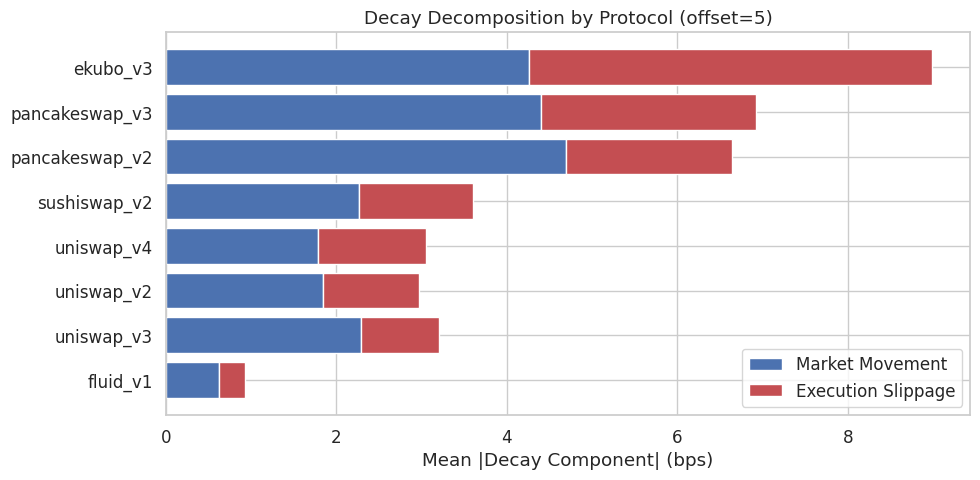

In [25]:
if decomp.height > 100:
    es_by_proto = (decomp.join(
        hd_full.filter(pl.col("block_offset") == 5)
        .select(["quote_id", "solver_id", "protocol"]).unique(),
        on=["quote_id", "solver_id"], how="left"
    ).filter(pl.col("protocol").is_not_null())
    .filter(pl.col("block_offset") == 5)
    .group_by("protocol").agg([
        pl.col("execution_slippage_bps").abs().mean().alias("mean_abs_es"),
        pl.col("market_movement_bps").abs().mean().alias("mean_abs_mm"),
        pl.len().alias("n"),
    ]).filter(pl.col("n") > 100)
    .sort("mean_abs_es", descending=True))

    if es_by_proto.height > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        protos_es = es_by_proto["protocol"].to_list()
        mm_vals = es_by_proto["mean_abs_mm"].to_numpy()
        es_vals = es_by_proto["mean_abs_es"].to_numpy()

        y = np.arange(len(protos_es))
        ax.barh(y, mm_vals, label="Market Movement", color=COLORS[0])
        ax.barh(y, es_vals, left=mm_vals, label="Execution Slippage", color=COLORS[3])
        ax.set_yticks(y)
        ax.set_yticklabels(protos_es)
        ax.set_xlabel("Mean |Decay Component| (bps)")
        ax.set_title("Decay Decomposition by Protocol (offset=5)")
        ax.legend()
        ax.invert_yaxis()
        fig.tight_layout()
        save(fig, "16_decomposition_by_protocol")

## 19. Data Quality Summary

In [26]:
print("\n" + "=" * 60)
print("FINAL DATA QUALITY SUMMARY")
print("=" * 60)
print(f"\nDataset: {df.shape[0]:,} rows, {df['quote_id'].n_unique():,} quotes")
print(f"Observation: ~{span_hours:.1f}h ({span_blocks:,} blocks)")
print(f"Decomposition fill: {fill_pct:.1f}%")
print(f"Pair classification coverage (mcap): {100*(1-mcap_null/df.shape[0]):.1f}%")
print(f"\nNull columns to address:")
print(f"  gap_to_second_best_bps: 100% null (BellmanFord uses SPFA, not candidate list)")
print(f"  log_mcap_ratio: {100*mcap_null/df.shape[0]:.1f}% null (need CoinGecko API for non-stable tokens)")
print(f"\nMissing data source:")
print(f"  eth_call ground truth (node-resim): not yet run on this dataset")
print(f"  → Cannot validate Tycho sim accuracy vs on-chain execution")


FINAL DATA QUALITY SUMMARY

Dataset: 2,863,603 rows, 297,712 quotes
Observation: ~44.5h (13,340 blocks)
Decomposition fill: 100.0%
Pair classification coverage (mcap): 96.9%

Null columns to address:
  gap_to_second_best_bps: 100% null (BellmanFord uses SPFA, not candidate list)
  log_mcap_ratio: 3.1% null (need CoinGecko API for non-stable tokens)

Missing data source:
  eth_call ground truth (node-resim): not yet run on this dataset
  → Cannot validate Tycho sim accuracy vs on-chain execution


## 20. Conditional Decay Distribution (decay > 0)

For a revert-prediction model we care about two distinct questions:
(1) **will** this route degrade? (classification), and
(2) **by how much?** (regression). This section examines the
conditional distribution -- given that a route degrades, how severe
is it? The unconditional distribution is dominated by zeros and
near-zeros which mask the tail that actually causes reverts.

=== Conditional Decay Distribution (offset=10, decay > 0) ===
N degraded routes: 119,626
  Percentile  Value (bps)
         P50         1.91
         P75         5.01
         P90         9.79
         P95        14.54
         P99        34.15


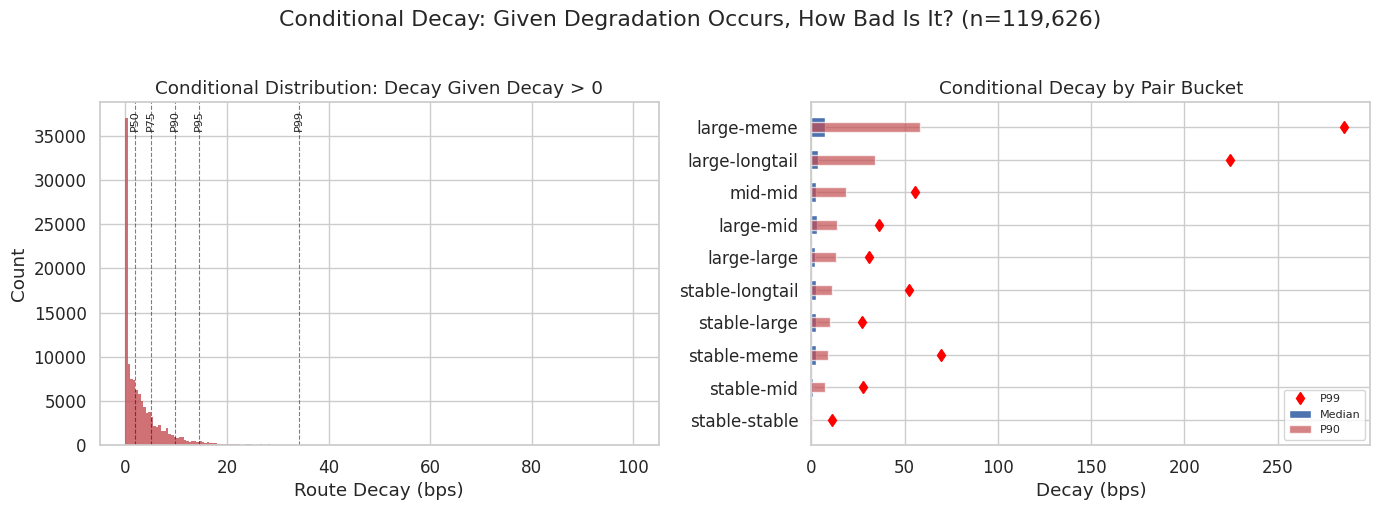

In [27]:
degraded = df.filter(
    (pl.col("block_offset") == 10) & (pl.col("route_decay_bps") > 0)
)
deg_vals = degraded["route_decay_bps"].to_numpy()
deg_vals = deg_vals[np.isfinite(deg_vals)]

pct_labels = [50, 75, 90, 95, 99]
pct_values = [np.percentile(deg_vals, p) for p in pct_labels]

print(f"=== Conditional Decay Distribution (offset=10, decay > 0) ===")
print(f"N degraded routes: {len(deg_vals):,}")
print(f"{'Percentile':>12} {'Value (bps)':>12}")
for label, val in zip(pct_labels, pct_values):
    print(f"{'P' + str(label):>12} {val:12.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(deg_vals, bins=200, range=(0, 100), color=COLORS[3], alpha=0.8,
             edgecolor="none")
for p_label, p_val in zip(pct_labels, pct_values):
    axes[0].axvline(p_val, color="black", linestyle="--", alpha=0.5, linewidth=0.8)
    axes[0].text(p_val, axes[0].get_ylim()[1] * 0.92, f"P{p_label}",
                 ha="center", fontsize=8, rotation=90)
axes[0].set_xlabel("Route Decay (bps)")
axes[0].set_ylabel("Count")
axes[0].set_title("Conditional Distribution: Decay Given Decay > 0")

cond_by_pair = (degraded.group_by("pair_bucket").agg([
    pl.col("route_decay_bps").median().alias("median"),
    pl.col("route_decay_bps").quantile(0.90).alias("p90"),
    pl.col("route_decay_bps").quantile(0.99).alias("p99"),
    pl.len().alias("n"),
]).filter(pl.col("n") > 50).sort("p90", descending=True))

if cond_by_pair.height > 0:
    pair_names = cond_by_pair["pair_bucket"].to_list()
    y_pos = np.arange(len(pair_names))
    medians_c = cond_by_pair["median"].to_numpy()
    p90_c = cond_by_pair["p90"].to_numpy()
    p99_c = cond_by_pair["p99"].to_numpy()

    axes[1].barh(y_pos, medians_c, height=0.6, label="Median", color=COLORS[0])
    axes[1].barh(y_pos, p90_c, height=0.3, label="P90", color=COLORS[3], alpha=0.7)
    for i, v99 in enumerate(p99_c):
        axes[1].plot(v99, i, "d", color="red", markersize=6)
    axes[1].plot([], [], "d", color="red", markersize=6, label="P99")
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(pair_names)
    axes[1].set_xlabel("Decay (bps)")
    axes[1].set_title("Conditional Decay by Pair Bucket")
    axes[1].legend(fontsize=8)
    axes[1].invert_yaxis()

fig.suptitle(
    f"Conditional Decay: Given Degradation Occurs, How Bad Is It? (n={len(deg_vals):,})",
    y=1.02,
)
fig.tight_layout()
save(fig, "17_conditional_decay_distribution")

In [28]:
print("\n--- Conditional stats by pair_bucket ---")
print(f"{'pair_bucket':>15} {'median':>8} {'P90':>8} {'P99':>8} {'n':>8}")
for row in cond_by_pair.iter_rows(named=True):
    print(f"{row['pair_bucket']:>15} {row['median']:8.2f} {row['p90']:8.2f} "
          f"{row['p99']:8.2f} {row['n']:8,}")


--- Conditional stats by pair_bucket ---
    pair_bucket   median      P90      P99        n
     large-meme     7.25    58.04   285.40      224
 large-longtail     3.44    34.29   224.18    1,752
        mid-mid     2.22    18.50    55.64    2,615
      large-mid     2.83    13.53    36.12    8,402
    large-large     1.86    12.98    31.12       72
stable-longtail     2.53    10.89    52.08   10,783
   stable-large     2.71    10.10    26.94   60,206
    stable-meme     2.30     8.83    69.69    1,670
     stable-mid     0.83     7.39    27.60   21,941
  stable-stable     0.01     0.14    11.09   11,857


## 21. Survival Curves (Revert Probability)

Survival analysis answers the question: "what fraction of routes
exceed a given decay threshold at each block offset?" This directly
maps to slippage tolerance decisions -- if P(decay > 20 bps) = 3%
at offset 5, Fynd can set a 20 bps tolerance knowing 97% of routes
will land within bounds.

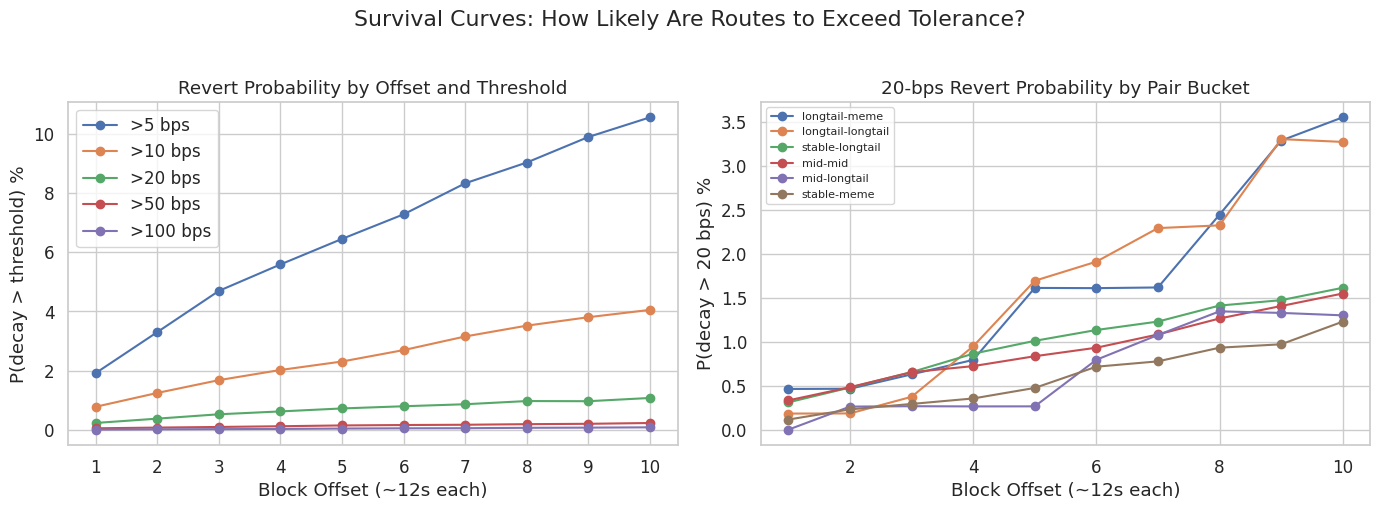

In [29]:
thresholds_bps = [5, 10, 20, 50, 100]

survival = (df.group_by("block_offset").agg([
    *[
        (pl.col("route_decay_bps") > t)
        .mean()
        .alias(f"p_gt_{t}")
        for t in thresholds_bps
    ],
    pl.len().alias("n"),
]).sort("block_offset"))

offsets_surv = survival["block_offset"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, t in enumerate(thresholds_bps):
    probs = survival[f"p_gt_{t}"].to_numpy() * 100
    axes[0].plot(offsets_surv, probs, "o-", label=f">{t} bps", color=COLORS[i])
axes[0].set_xlabel("Block Offset (~12s each)")
axes[0].set_ylabel("P(decay > threshold) %")
axes[0].set_title("Revert Probability by Offset and Threshold")
axes[0].legend()
axes[0].set_xticks(offsets_surv)

# Stratify the 20-bps threshold by pair_bucket
surv_by_pair = (df.group_by(["block_offset", "pair_bucket"]).agg([
    (pl.col("route_decay_bps") > 20).mean().alias("p_gt_20"),
    pl.len().alias("n"),
]).filter(pl.col("n") > 100).sort("block_offset"))

pair_buckets_list = (surv_by_pair.group_by("pair_bucket")
    .agg(pl.col("p_gt_20").max().alias("max_p"))
    .sort("max_p", descending=True)["pair_bucket"].to_list())

for i, pb in enumerate(pair_buckets_list[:6]):
    sub = surv_by_pair.filter(pl.col("pair_bucket") == pb).sort("block_offset")
    axes[1].plot(
        sub["block_offset"].to_numpy(),
        sub["p_gt_20"].to_numpy() * 100,
        "o-", label=pb, color=COLORS[i % len(COLORS)],
    )
axes[1].set_xlabel("Block Offset (~12s each)")
axes[1].set_ylabel("P(decay > 20 bps) %")
axes[1].set_title("20-bps Revert Probability by Pair Bucket")
axes[1].legend(fontsize=8)

fig.suptitle("Survival Curves: How Likely Are Routes to Exceed Tolerance?", y=1.02)
fig.tight_layout()
save(fig, "18_survival_curves")

In [30]:
print("\n=== Survival table: P(decay > threshold) at each offset ===")
header = f"{'offset':>6}" + "".join(f"{'>' + str(t) + 'bps':>10}" for t in thresholds_bps)
print(header)
for row in survival.iter_rows(named=True):
    vals = "".join(
        f"{100 * row[f'p_gt_{t}']:9.2f}%"
        for t in thresholds_bps
    )
    print(f"{row['block_offset']:>6}{vals}")


=== Survival table: P(decay > threshold) at each offset ===
offset     >5bps    >10bps    >20bps    >50bps   >100bps
     1     1.92%     0.78%     0.24%     0.06%     0.01%
     2     3.30%     1.25%     0.38%     0.08%     0.02%
     3     4.69%     1.68%     0.53%     0.10%     0.03%
     4     5.58%     2.02%     0.63%     0.13%     0.03%
     5     6.45%     2.31%     0.73%     0.15%     0.05%
     6     7.28%     2.70%     0.80%     0.17%     0.06%
     7     8.32%     3.15%     0.87%     0.18%     0.06%
     8     9.02%     3.52%     0.98%     0.20%     0.07%
     9     9.88%     3.80%     0.97%     0.21%     0.08%
    10    10.55%     4.05%     1.08%     0.23%     0.09%


## 22. Decay Velocity / Acceleration

Is decay linear, concave, or convex over time? If concave (velocity
decreasing), the worst damage happens in the first 1-2 blocks and
fast execution matters most. If convex (velocity increasing), pending
routes get exponentially worse and Fynd should aggressively re-quote.
This shapes the re-quote scheduling strategy.

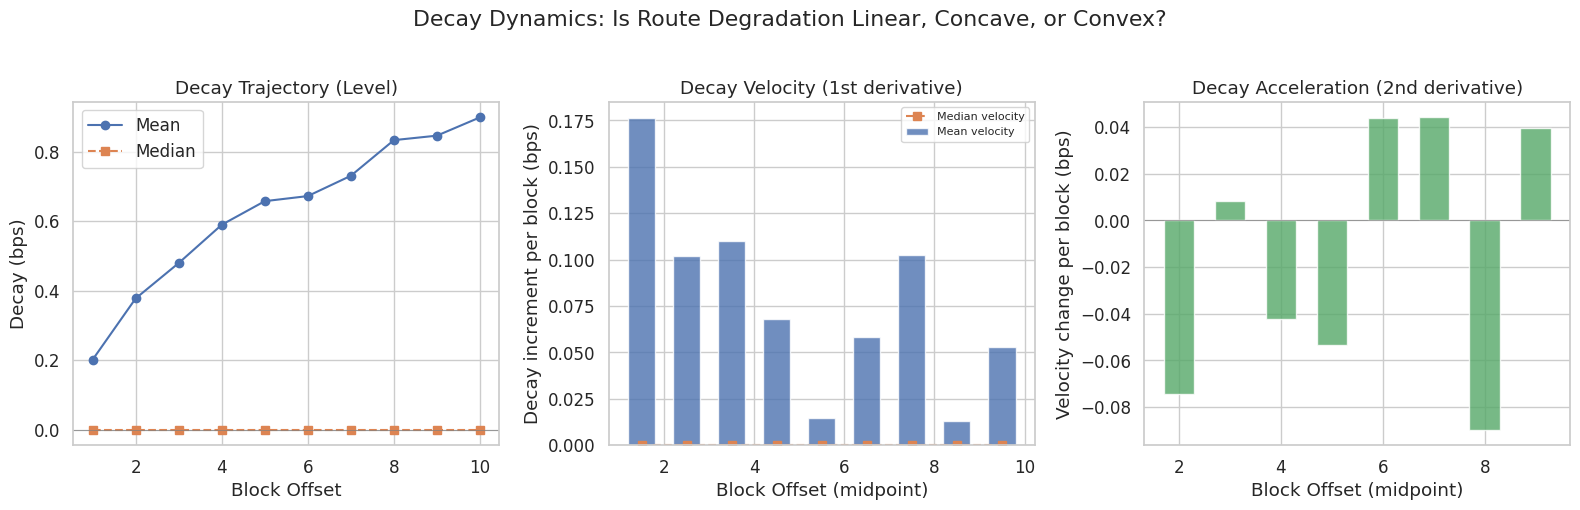

In [31]:
# Compute per-offset mean decay, then derive velocity (delta between offsets)
decay_by_off = (df.group_by("block_offset").agg([
    pl.col("route_decay_bps").mean().alias("mean_decay"),
    pl.col("route_decay_bps").median().alias("median_decay"),
]).sort("block_offset"))

off_arr = decay_by_off["block_offset"].to_numpy()
mean_arr = decay_by_off["mean_decay"].to_numpy()
median_arr = decay_by_off["median_decay"].to_numpy()

# Velocity = difference between consecutive offsets
velocity_mean = np.diff(mean_arr)
velocity_median = np.diff(median_arr)
velocity_offsets = (off_arr[:-1] + off_arr[1:]) / 2

# Acceleration = difference of velocity
accel_mean = np.diff(velocity_mean)
accel_offsets = (velocity_offsets[:-1] + velocity_offsets[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(off_arr, mean_arr, "o-", color=COLORS[0], label="Mean")
axes[0].plot(off_arr, median_arr, "s--", color=COLORS[1], label="Median")
axes[0].set_xlabel("Block Offset")
axes[0].set_ylabel("Decay (bps)")
axes[0].set_title("Decay Trajectory (Level)")
axes[0].legend()
axes[0].axhline(0, color="grey", linewidth=0.5)

axes[1].bar(velocity_offsets, velocity_mean, width=0.6, color=COLORS[0],
            alpha=0.8, label="Mean velocity")
axes[1].plot(velocity_offsets, velocity_median, "s--", color=COLORS[1],
             label="Median velocity")
axes[1].set_xlabel("Block Offset (midpoint)")
axes[1].set_ylabel("Decay increment per block (bps)")
axes[1].set_title("Decay Velocity (1st derivative)")
axes[1].legend(fontsize=8)
axes[1].axhline(0, color="grey", linewidth=0.5)

axes[2].bar(accel_offsets, accel_mean, width=0.6, color=COLORS[2], alpha=0.8)
axes[2].set_xlabel("Block Offset (midpoint)")
axes[2].set_ylabel("Velocity change per block (bps)")
axes[2].set_title("Decay Acceleration (2nd derivative)")
axes[2].axhline(0, color="grey", linewidth=0.5)

fig.suptitle("Decay Dynamics: Is Route Degradation Linear, Concave, or Convex?", y=1.02)
fig.tight_layout()
save(fig, "19_decay_velocity")

In [32]:
print("\n=== Decay velocity analysis ===")
print(f"{'offset_mid':>10} {'velocity_mean':>14} {'velocity_median':>16}")
for o, vm, vmed in zip(velocity_offsets, velocity_mean, velocity_median):
    print(f"{o:>10.1f} {vm:>14.4f} {vmed:>16.4f}")

early_v = velocity_mean[:2].mean()
late_v = velocity_mean[-2:].mean()
if early_v > late_v * 1.3:
    shape = "CONCAVE (front-loaded)"
    interpretation = "Most damage in first 1-2 blocks; fast execution is critical."
elif late_v > early_v * 1.3:
    shape = "CONVEX (back-loaded)"
    interpretation = "Decay accelerates over time; pending routes get exponentially worse."
else:
    shape = "APPROXIMATELY LINEAR"
    interpretation = "Decay grows at a roughly constant rate per block."
print(f"\nDecay shape: {shape}")
print(f"Interpretation: {interpretation}")
print(f"  Early velocity (offsets 1-2): {early_v:.4f} bps/block")
print(f"  Late velocity  (offsets 8-9): {late_v:.4f} bps/block")


=== Decay velocity analysis ===
offset_mid  velocity_mean  velocity_median
       1.5         0.1762           0.0000
       2.5         0.1018           0.0000
       3.5         0.1101           0.0000
       4.5         0.0679           0.0000
       5.5         0.0146           0.0000
       6.5         0.0584           0.0000
       7.5         0.1026           0.0000
       8.5         0.0129           0.0000
       9.5         0.0527           0.0000

Decay shape: CONCAVE (front-loaded)
Interpretation: Most damage in first 1-2 blocks; fast execution is critical.
  Early velocity (offsets 1-2): 0.1390 bps/block
  Late velocity  (offsets 8-9): 0.0328 bps/block


## 23. Tail Decomposition (Market Movement vs Execution Slippage by Severity)

The global decomposition split is ~65/35 market-movement vs execution-
slippage. But does the controllable fraction (execution slippage)
change for the worst routes? If execution slippage dominates in
the tail, Fynd has more room to improve on the cases that matter
most -- the ones that cause reverts.

=== Tail Decomposition: Market Movement vs Execution Slippage ===
           Band        n   MM share   ES share   mean|MM|   mean|ES|
     All routes  286,842      63.7%      36.3%       1.85       1.05
        >10 bps    6,625      61.0%      39.0%      17.27      11.06
        >20 bps    2,084      65.1%      34.9%      37.98      20.35
        >50 bps      439      69.1%      30.9%     111.98      49.98


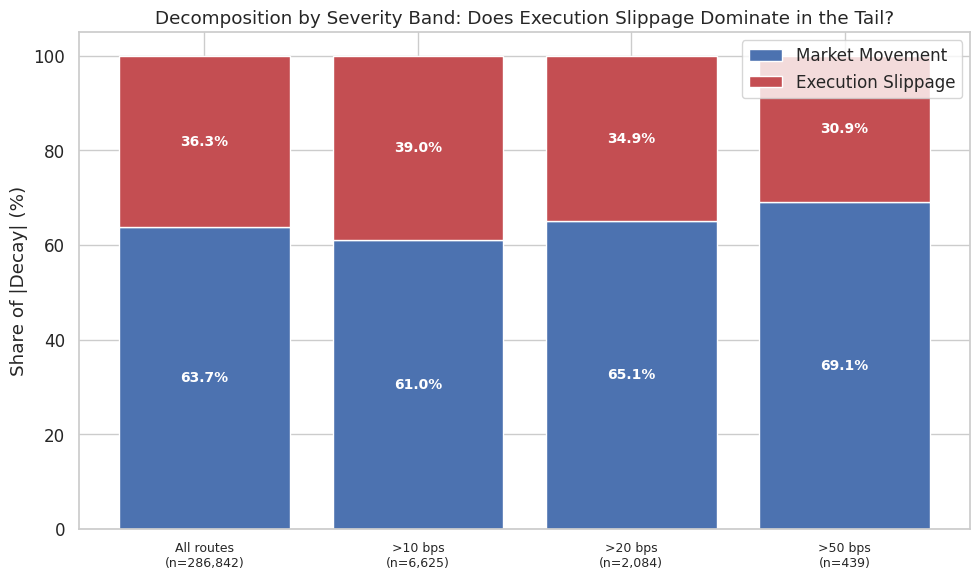


Execution slippage share DECREASES in the tail (36.3% -> 30.9%)
Tail decay is mostly market-driven; Fynd's leverage is limited.


In [33]:
if decomp.height > 100:
    severity_bands = [
        ("All routes", decomp.filter(pl.col("block_offset") == 5)),
        (">10 bps", decomp.filter(
            (pl.col("block_offset") == 5) & (pl.col("route_decay_bps") > 10)
        )),
        (">20 bps", decomp.filter(
            (pl.col("block_offset") == 5) & (pl.col("route_decay_bps") > 20)
        )),
        (">50 bps", decomp.filter(
            (pl.col("block_offset") == 5) & (pl.col("route_decay_bps") > 50)
        )),
    ]

    band_labels = []
    mm_shares = []
    es_shares = []
    band_ns = []

    print("=== Tail Decomposition: Market Movement vs Execution Slippage ===")
    print(f"{'Band':>15} {'n':>8} {'MM share':>10} {'ES share':>10} "
          f"{'mean|MM|':>10} {'mean|ES|':>10}")

    for label, band_df in severity_bands:
        if band_df.height < 10:
            continue
        mm_abs = band_df["market_movement_bps"].abs().sum()
        es_abs = band_df["execution_slippage_bps"].abs().sum()
        total = mm_abs + es_abs
        mm_pct = 100 * mm_abs / total if total > 0 else 0
        es_pct = 100 * es_abs / total if total > 0 else 0

        mm_mean = band_df["market_movement_bps"].abs().mean()
        es_mean = band_df["execution_slippage_bps"].abs().mean()

        band_labels.append(f"{label}\n(n={band_df.height:,})")
        mm_shares.append(mm_pct)
        es_shares.append(es_pct)
        band_ns.append(band_df.height)

        print(f"{label:>15} {band_df.height:>8,} {mm_pct:>9.1f}% {es_pct:>9.1f}% "
              f"{mm_mean:>10.2f} {es_mean:>10.2f}")

    if len(band_labels) > 1:
        fig, ax = plt.subplots(figsize=(10, 6))
        x_pos = np.arange(len(band_labels))
        ax.bar(x_pos, mm_shares, label="Market Movement", color=COLORS[0])
        ax.bar(x_pos, es_shares, bottom=mm_shares, label="Execution Slippage",
               color=COLORS[3])
        ax.set_xticks(x_pos)
        ax.set_xticklabels(band_labels, fontsize=9)
        ax.set_ylabel("Share of |Decay| (%)")
        ax.set_title(
            "Decomposition by Severity Band: Does Execution Slippage "
            "Dominate in the Tail?"
        )
        ax.legend()
        ax.set_ylim(0, 105)
        for i in range(len(band_labels)):
            ax.text(i, mm_shares[i] / 2, f"{mm_shares[i]:.1f}%",
                    ha="center", va="center", fontsize=10, fontweight="bold",
                    color="white")
            ax.text(i, mm_shares[i] + es_shares[i] / 2, f"{es_shares[i]:.1f}%",
                    ha="center", va="center", fontsize=10, fontweight="bold",
                    color="white")

        fig.tight_layout()
        save(fig, "20_tail_decomposition")

    # Summary interpretation
    if len(mm_shares) >= 3:
        all_es = es_shares[0]
        tail_es = es_shares[-1]
        if tail_es > all_es + 5:
            print(f"\nExecution slippage share INCREASES in the tail "
                  f"({all_es:.1f}% -> {tail_es:.1f}%)")
            print("Fynd has MORE room to improve on the worst cases.")
        elif tail_es < all_es - 5:
            print(f"\nExecution slippage share DECREASES in the tail "
                  f"({all_es:.1f}% -> {tail_es:.1f}%)")
            print("Tail decay is mostly market-driven; Fynd's leverage is limited.")
        else:
            print(f"\nExecution slippage share is STABLE across severity bands "
                  f"({all_es:.1f}% -> {tail_es:.1f}%)")
            print("The controllable fraction stays consistent regardless of severity.")

## 24. Key Takeaways

1. **Directional bias**: 34.7% of routes degrade vs 18.9% that improve
   (46.5% unchanged). Among routes that move, degradation outweighs
   improvement nearly 2:1.

2. **Market movement vs execution slippage**: With 100% decomposition
   fill rate, the split is representative. Market movement accounts
   for ~64.7% of total |decay|; execution slippage accounts for ~35.3%.
   However, this split should be treated as directionally informative
   due to re-quote variability (see Decomposition Limitations).

3. **Fee tier is the strongest structural predictor**: Low-fee pools
   serve volatile pairs and show the highest decay. This is confounded
   (volatile pairs -> low fee pools), not causal.

4. **Protocol differences are significant**: Kruskal-Wallis confirms.
   Differences may reflect pair mix rather than protocol mechanics.

5. **Pair type (CoinGecko-enriched, 13 categories)**: `longtail-meme`
   has the highest raw mean decay at 3.76 bps. `stable-meme` (-0.68 bps)
   and `mid-mid` (-0.31 bps) show negative mean decay, meaning routes
   through these pairs tend to improve over time. `stable-large` (1.36 bps
   raw mean) remains the highest-volume high-decay category, making it
   the most impactful target for revert reduction.

6. **Tail risk**: 1.08% of routes have >20 bps decay at offset 10.
   Mean decay is 0.626 bps (winsorized 0.523 bps).

7. **What Fynd can improve**: Execution slippage (the controllable
   component) accounts for ~35.3% of decay. Targeting high-decay pools
   and pair types could reduce revert rates.

## 25. Feature Recommendations for Prediction Model

| Feature | At quote time? | Notes |
|---------|----------------|-------|
| `fee_tier` | Yes | Strongest structural predictor |
| `pair_bucket` | Yes (CoinGecko) | Pair type classification |
| `hop_count` | Yes | More hops = more compounding risk |
| `depth_at_1pct` | Yes | Confounded with volatility |
| `protocol` | Yes | Significant differences |
| `hour_of_day` | Yes | Intraday seasonality |
| `split_count` | Yes | Route complexity indicator |
| `gas_estimate` | Yes | Weak correlation |
| `market_movement_bps` | **No** | Only known after resim |
| `max_hop_decay_bps` | **No** | Only known after resim |